In [260]:
# ================================================================================
# Splitting training and test sets
# ================================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

data=pd.read_csv('WAGE2_2025_abridged.csv')

state=530088808+540338216+540527739+530800484+530356855 # replace this number with the sum of the student IDs for the members of your group

train = data.sample(frac=0.8, random_state=state)
test = data[data.index.isin(train.index)==False].copy() # Only for prediction

train=train.reset_index(drop = True)
test=test.reset_index(drop = True)


# **Data cleaning**

The original data matrix contains 733 rows for training data, 183 rows for test data, and 17 columns for both. 

We realize that there are rows with null values, so our first step is to check if we can clean the data through dropping all the rows with at least 1 null value. This is done by comparing the distribution of data without any droppings and after dropping. The graphs show much similarities and no visible distinctions, so we decide to proceed with this cleaning method. 


After cleaning, we retained 531 observations for the training data and 124 observations for the test data. 

This approach raises concerns in data loss and statistical power as after reduction only around 2/3 of the original data remain (total 655 rows). Nevertheless, with much distribution similarities before and after dropping null values, we aim to keep data reliability, avoid introducing bias or analysis errors, and avoid false assumptions. We believe that the 655 remaining data points can provide reasonable information for meaningful analysis. 

(733, 17)
(183, 17)


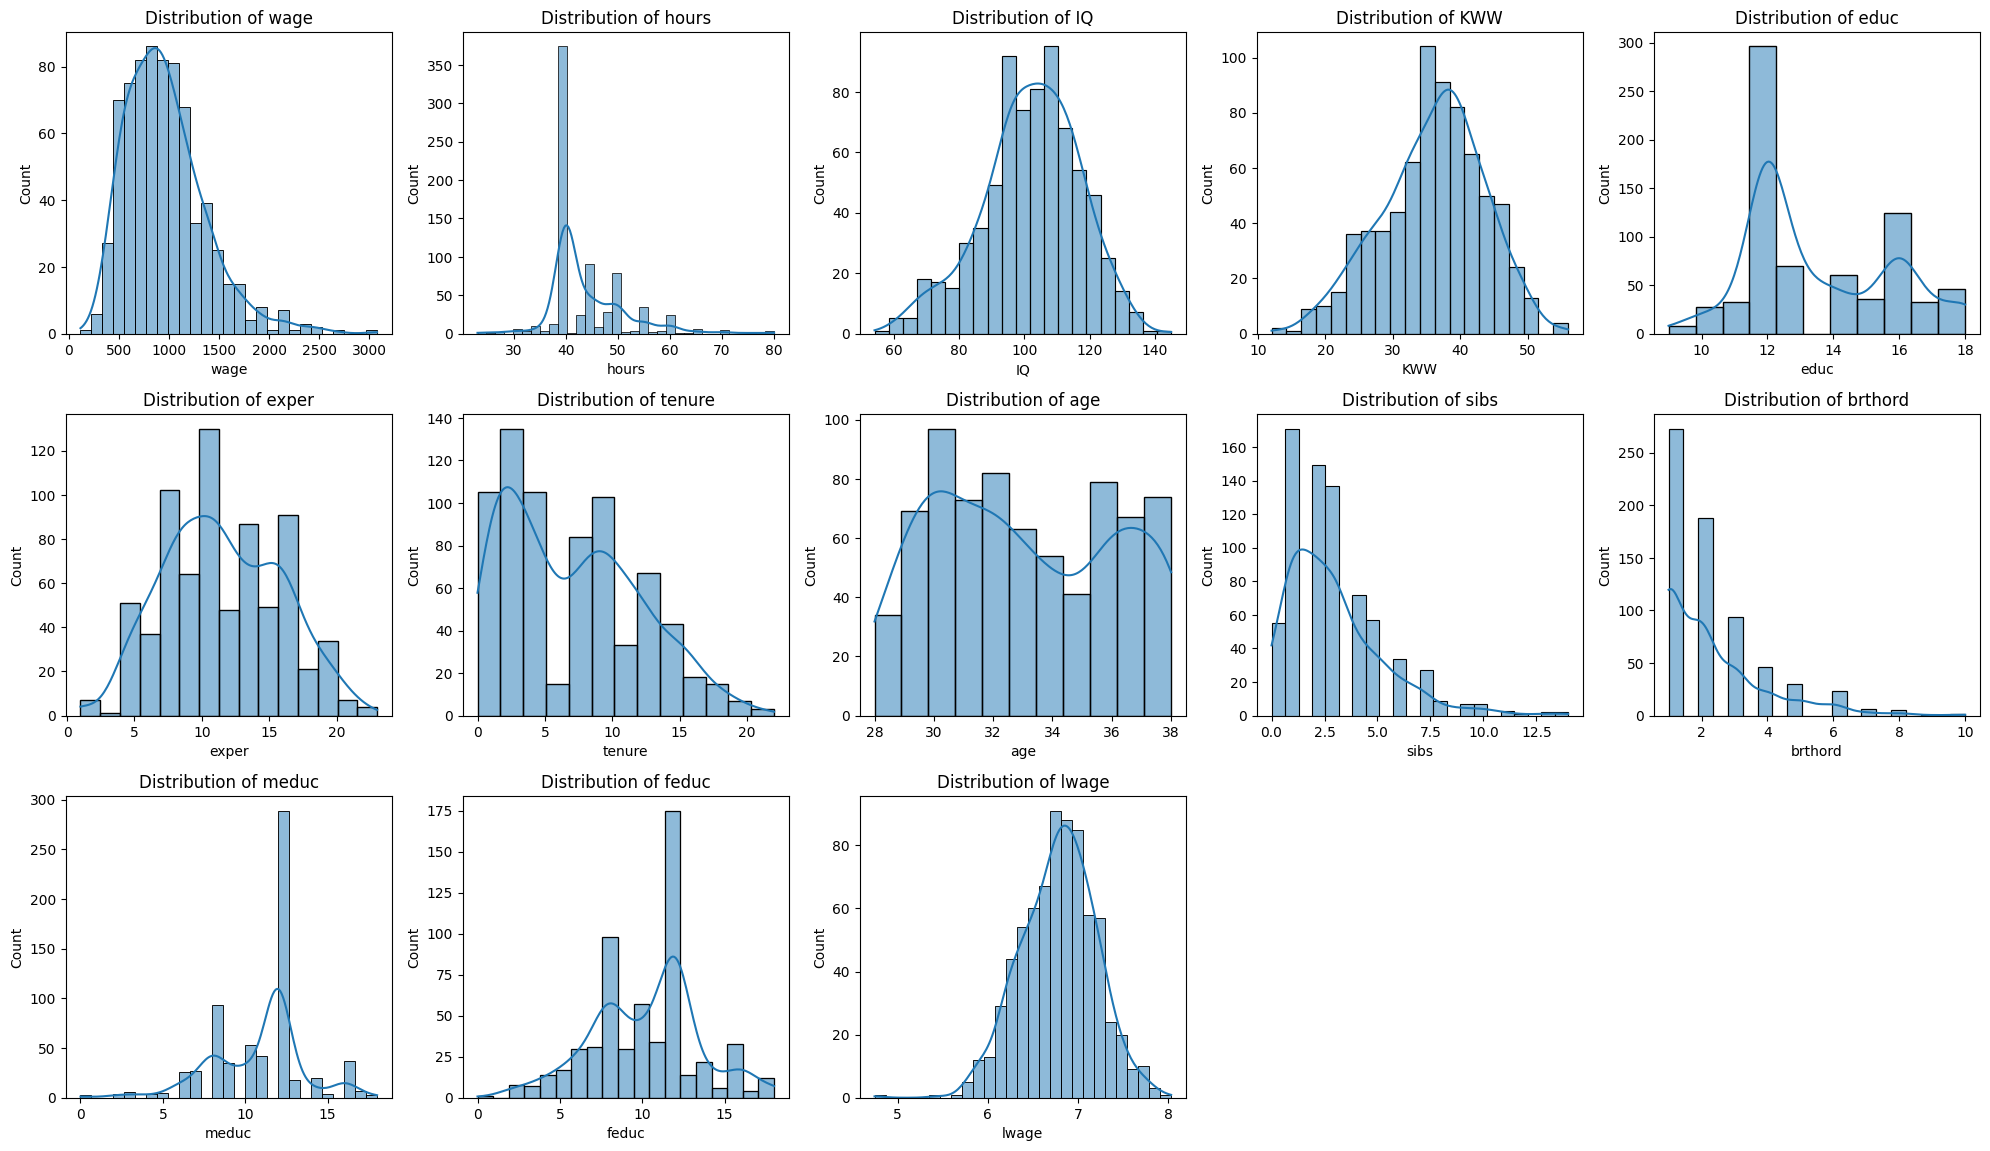

In [261]:


print(train.shape) #Check dimensions of training data
print(test.shape) #Check dimensions of test data


#Check if there are null values 
train.isnull().any()
test.isnull().any()


variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(train[var],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()


In [262]:

#Drop null values
train=train.dropna()    
test=test.dropna()     

print(train.shape)        #Training data original: 733, after cleaning: 531, change = 202
print(test.shape)         #Test data original: 183, after cleaning: 124, change = 59

#Total change: 202 + 59 = 261

(531, 17)
(124, 17)


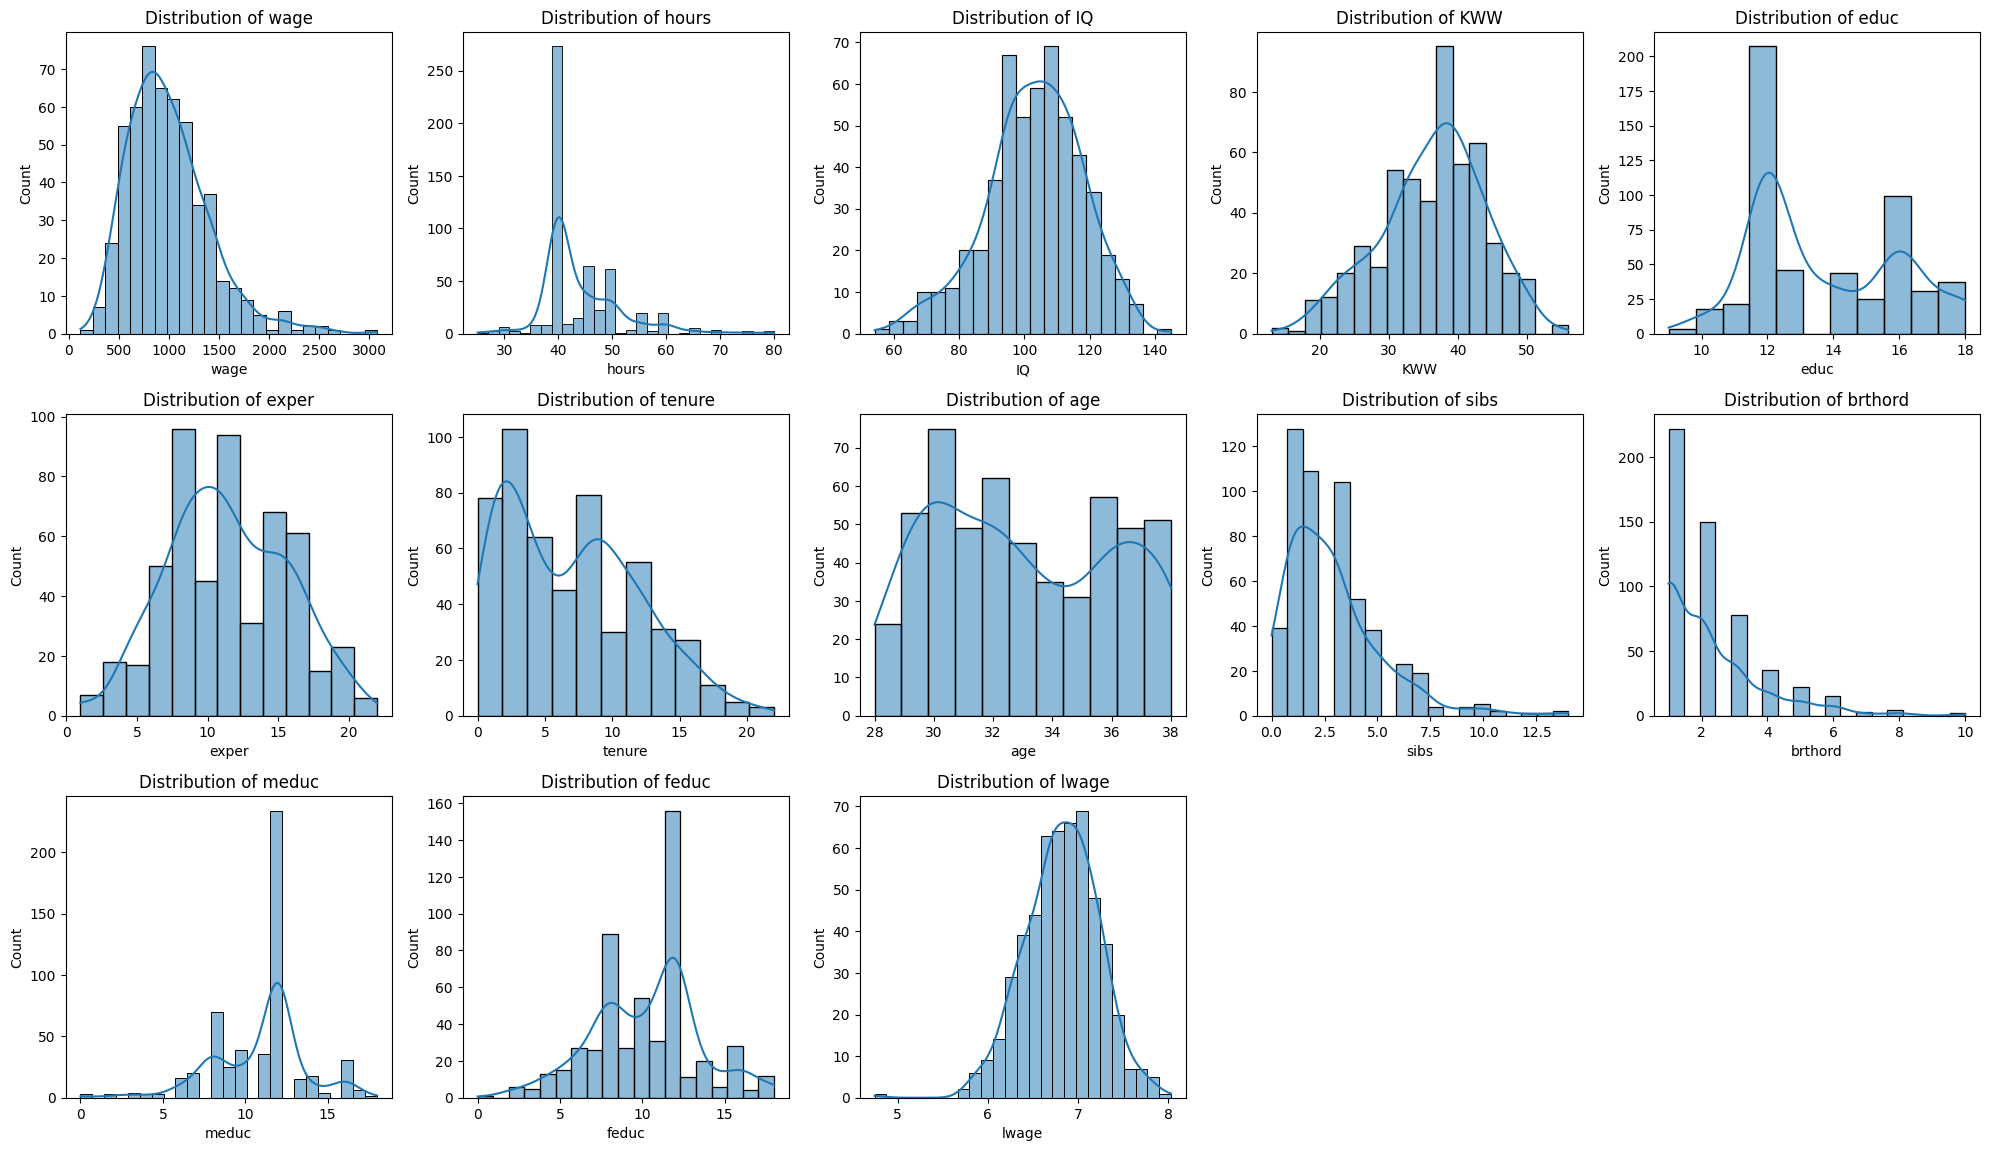

In [263]:
#Distribution of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(train[var],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# **Task 1: Exploratory analysis**



In [266]:
# Check the first few rows of the training data
train.head()

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
0,962,40,85,41,10,15,16,38,1,0,0,1,1,2.0,9.0,12.0,6.869014
2,894,40,104,35,18,7,10,35,1,0,1,0,7,8.0,9.0,8.0,6.795706
3,1250,40,92,42,16,10,11,32,0,0,1,1,1,1.0,12.0,10.0,7.130899
4,550,46,95,44,12,18,15,35,1,0,0,1,1,1.0,12.0,11.0,6.309918
5,600,40,114,36,16,5,4,30,1,0,1,1,2,1.0,12.0,12.0,6.396930


In [267]:
# Check the first 5 rows of test data
test.head()

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
1,1318,38,119,24,16,7,2,28,1,0,0,1,3,1.0,10.0,10.0,7.183871
2,1792,40,118,47,16,9,9,34,1,0,0,1,1,1.0,12.0,12.0,7.491087
7,1274,40,106,35,13,11,12,31,1,0,0,1,0,1.0,15.0,12.0,7.149917
8,692,40,108,48,12,21,11,38,1,0,0,1,3,1.0,8.0,7.0,6.539586
10,808,60,109,47,13,14,12,38,1,0,0,1,2,2.0,12.0,10.0,6.694562


In [268]:
# EDA after cleaning
train.describe().round(2)
test.describe().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
count,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00,124.00
mean,957.16,44.08,100.48,35.73,13.55,11.23,7.94,32.84,0.90,0.09,0.27,0.70,2.69,2.02,10.54,10.26,6.78
std,401.36,6.83,14.22,7.55,2.16,4.23,5.15,2.89,0.31,0.29,0.44,0.46,2.08,1.29,2.94,3.25,0.43
min,200.00,32.00,66.00,19.00,9.00,1.00,0.00,28.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,3.00,5.30
25%,687.25,40.00,91.00,30.00,12.00,8.00,3.00,30.00,1.00,0.00,0.00,0.00,1.00,1.00,8.00,8.00,6.53
50%,943.50,40.00,99.50,36.50,12.00,11.00,8.00,32.50,1.00,0.00,0.00,1.00,2.00,2.00,12.00,10.00,6.85
75%,1154.25,48.00,109.25,41.00,16.00,14.25,12.00,35.00,1.00,0.00,1.00,1.00,3.00,2.00,12.00,12.00,7.05
max,2771.00,70.00,134.00,49.00,18.00,21.00,20.00,38.00,1.00,1.00,1.00,1.00,13.00,7.00,18.00,18.00,7.93


### **a. Distribution of numerical variables vs wage**

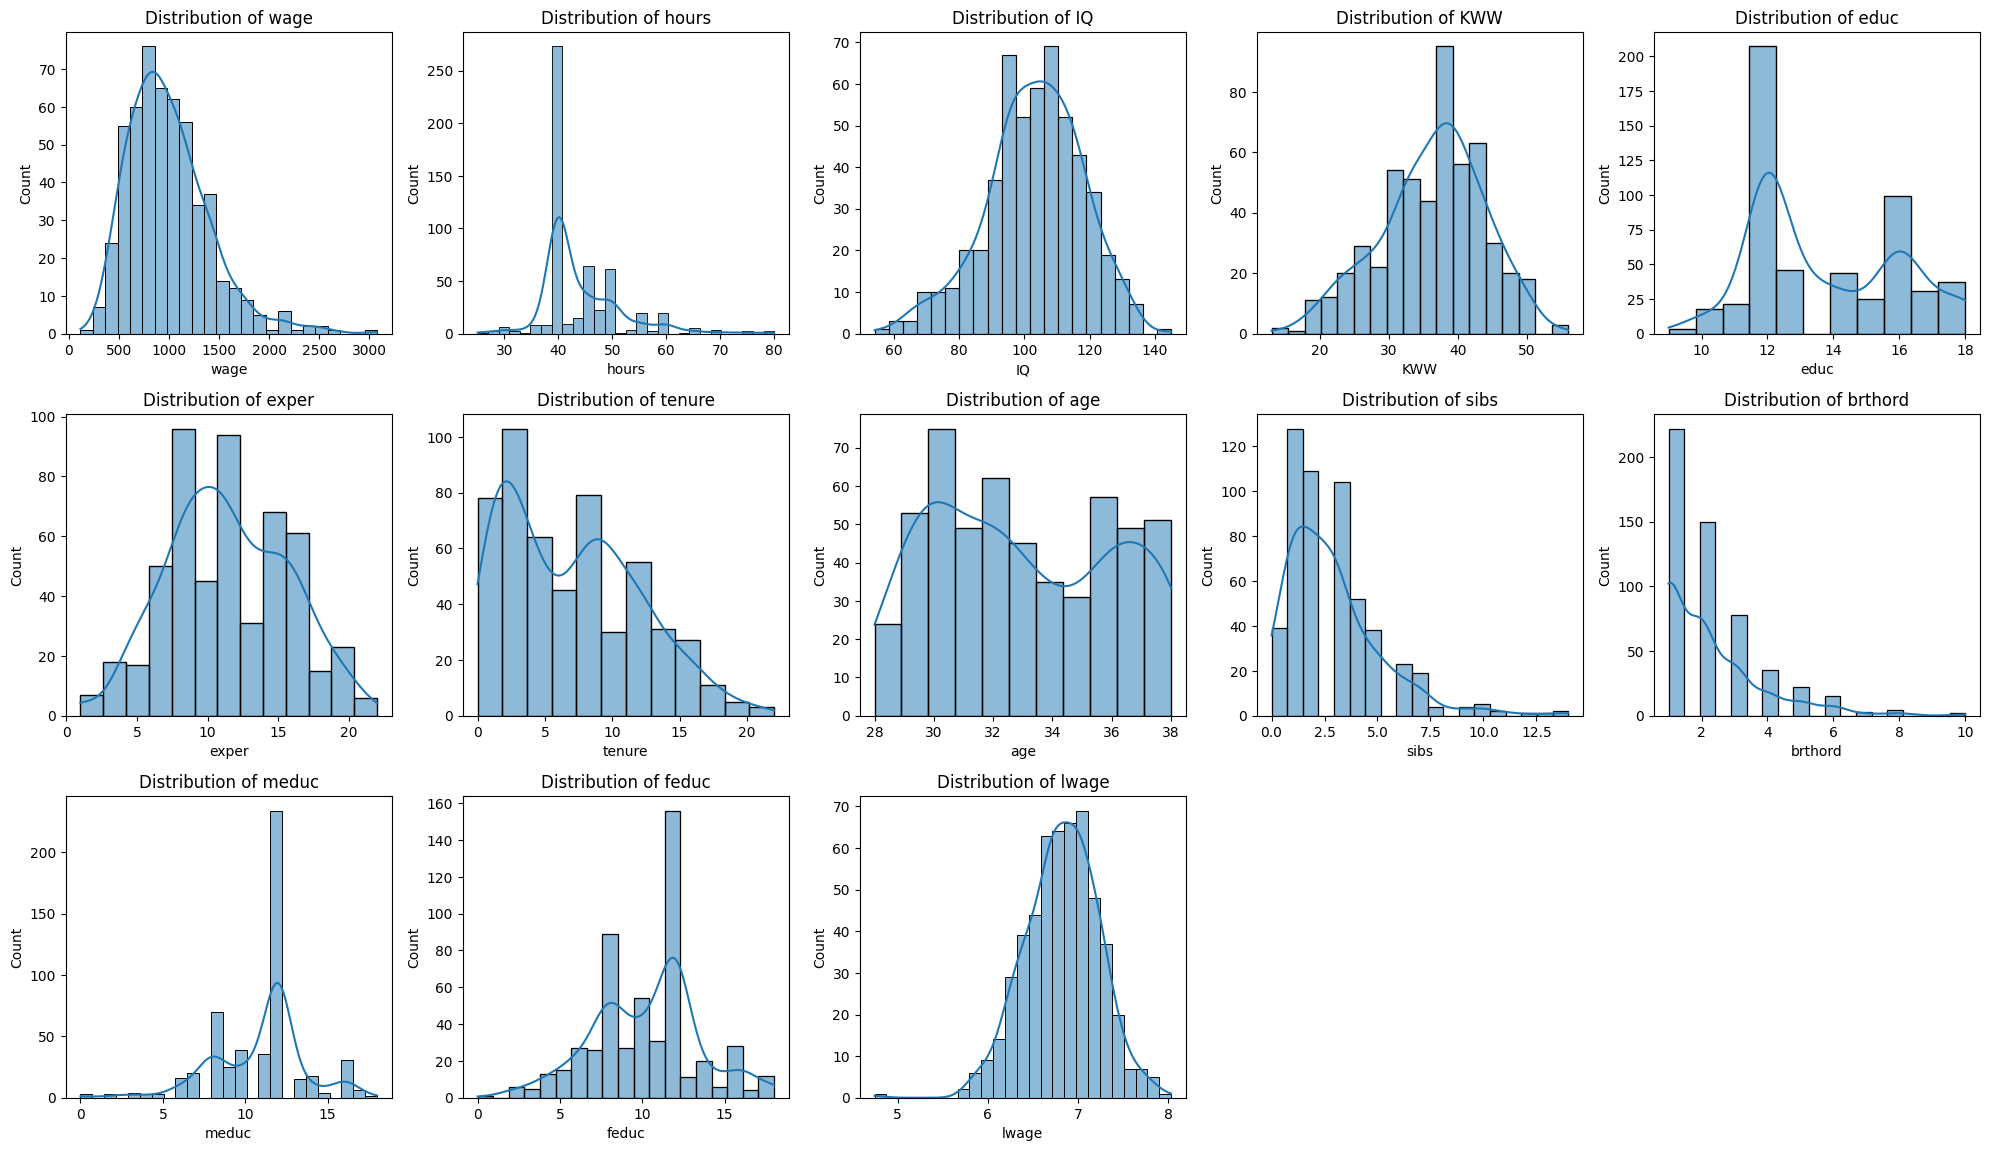

In [269]:
#Distribution of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.histplot(train[var],kde=True,ax=axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

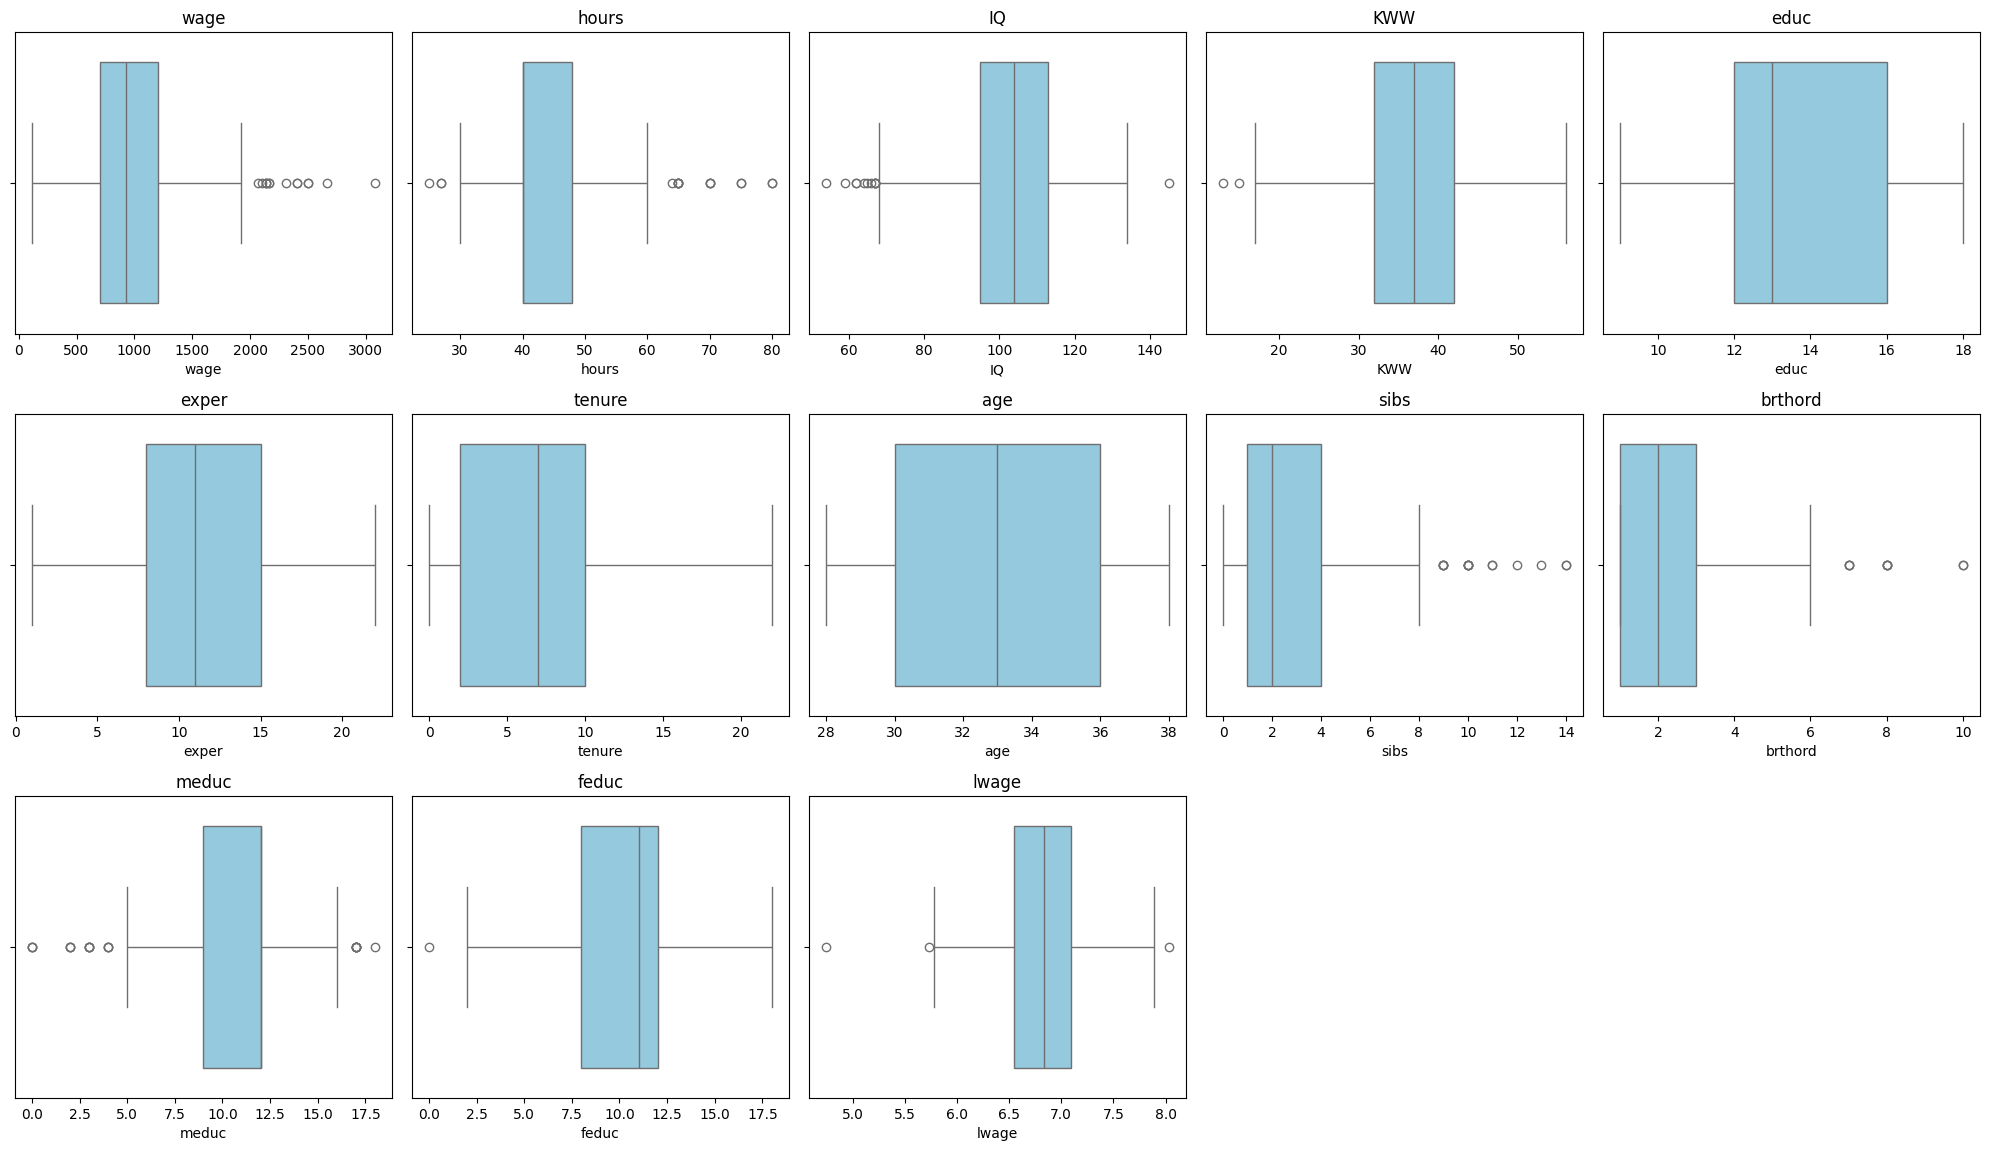

In [270]:
#boxplots of numerical variables
variables = ['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','sibs','brthord','meduc','feduc','lwage']
n_cols=5
n_rows=4
fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,15))
axes=axes.flatten()
for i, var in enumerate(variables):
    sns.boxplot(x=train[var],ax=axes[i],color='skyblue')
    axes[i].set_title(f'{var}')
    axes[i].set_ylabel('')
for j in range (i+1,len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

The distribution of wage is skewed heavily to the right, indicating that most individuals earn around the lower range, and a few high-earners that push the tail.

In both sets of graphs, IQ, KWW, exper, educ, and lwage seem to be approximately normally distributed. This suggests that they could be used for future modelling stages, but assumptions remain unchecked and visual interpretation might not be completely correct. 

The variable lwage (log of wage) follows somewhat a normal distribution; therefore we can consider this for transformation effects in future stages. 

### **b. Distribution of categorical variables vs wage**

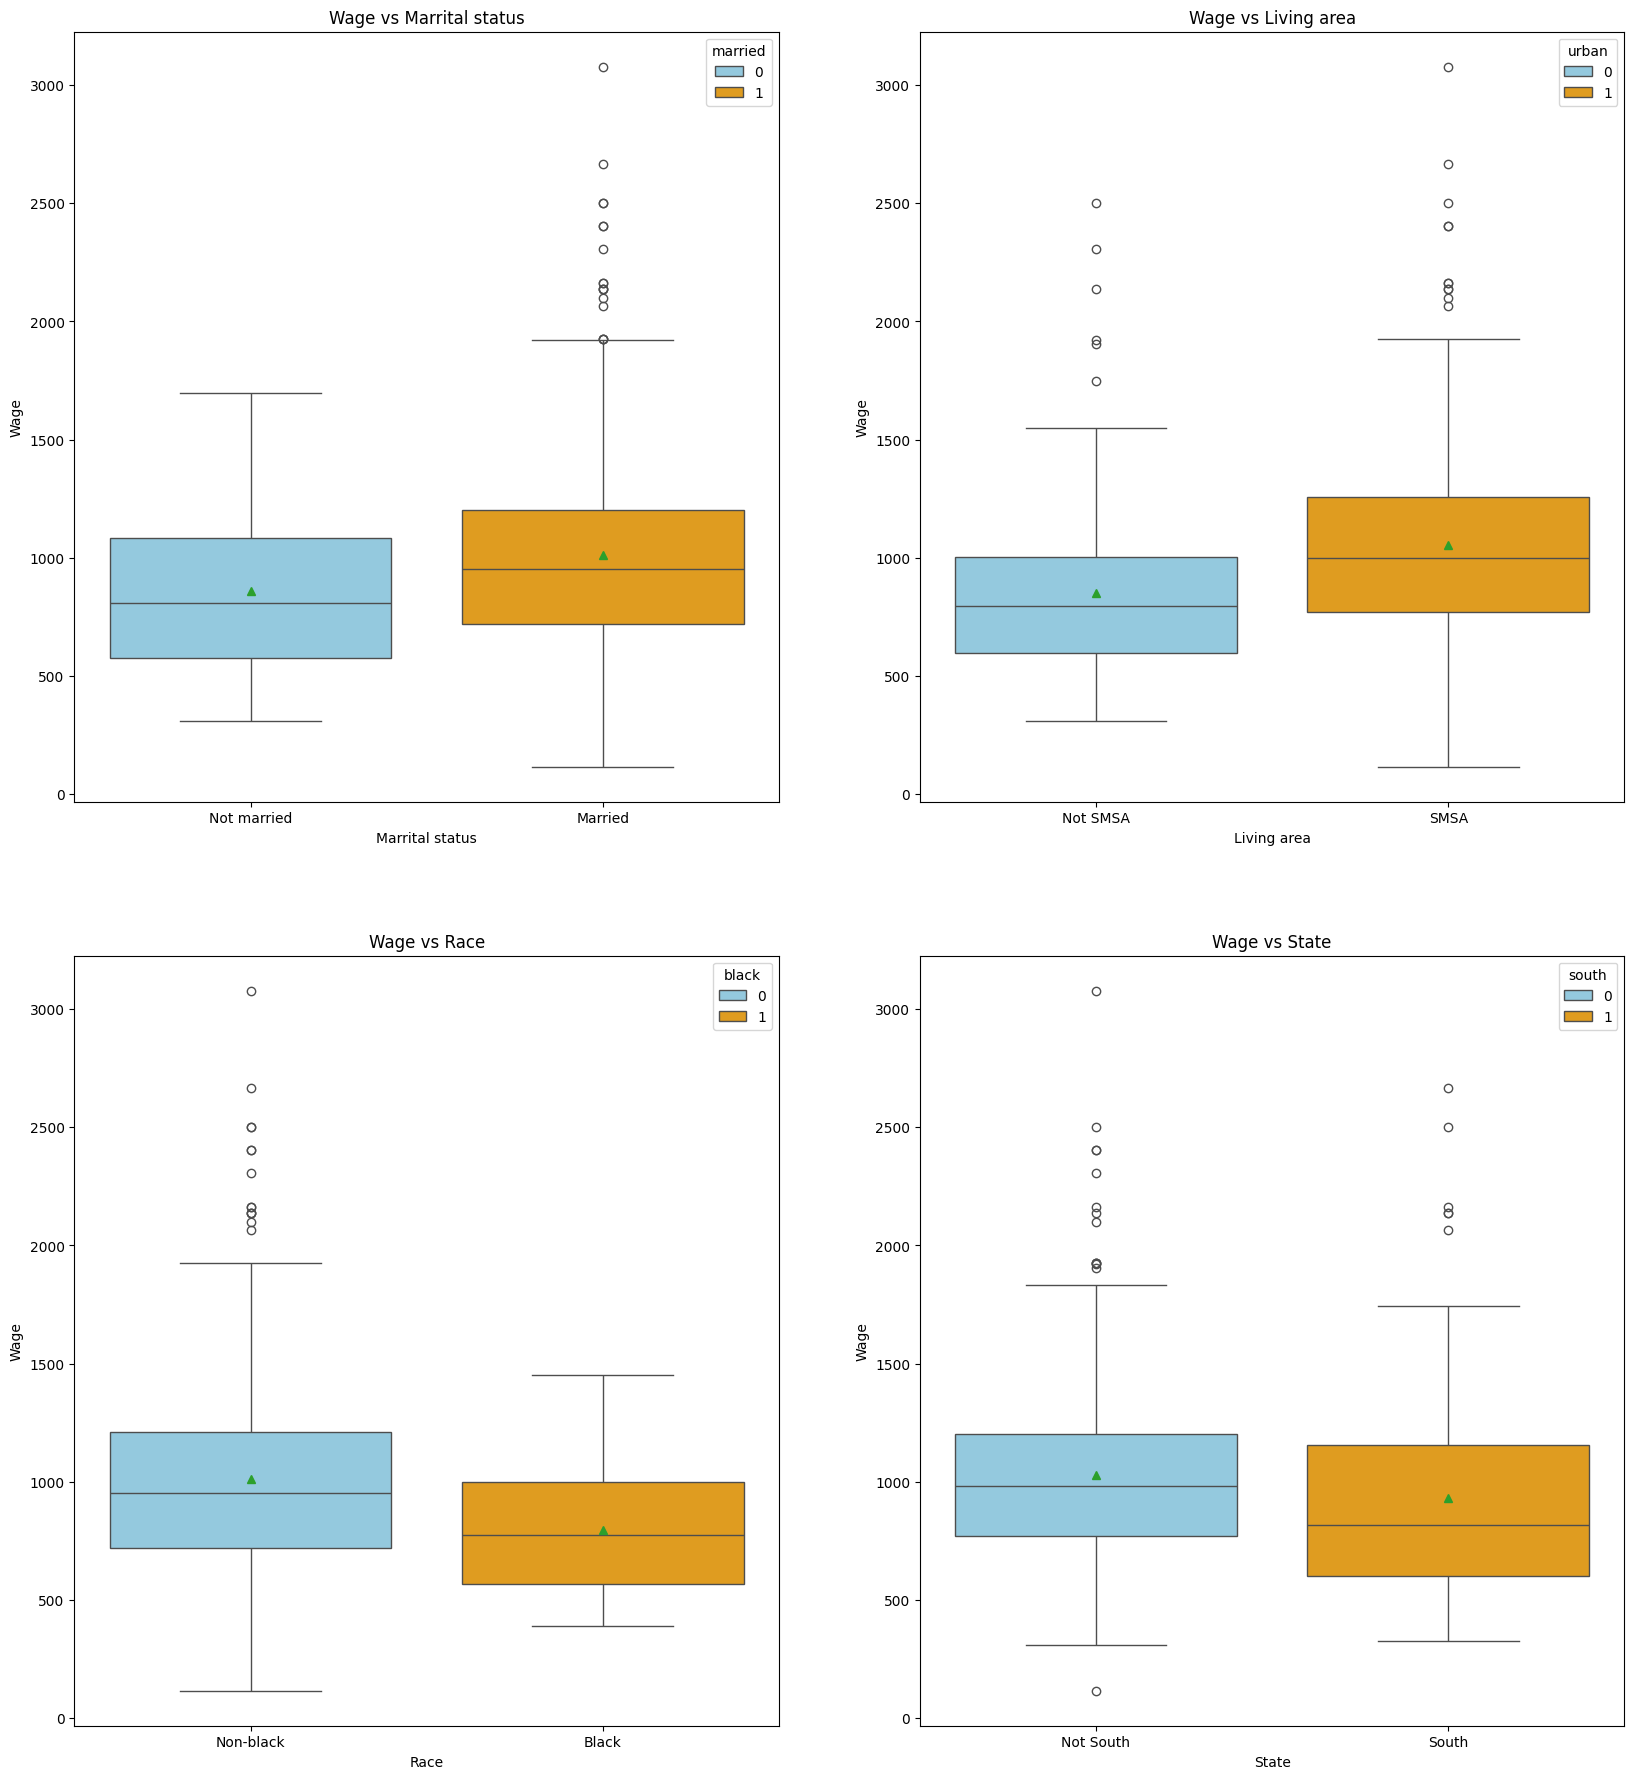

In [271]:
#side-by-side boxplots of wages vs categorical variabes
fig,ax=plt.subplots(2,2,figsize=(20,22))
sns.boxplot(x=train['married'],y=train['wage'],hue=train['married'],palette=['skyblue','orange'],ax=ax[0,0],showmeans=True)
ax[0,0].set_title('Wage vs Marrital status')
ax[0,0].set_xlabel('Marrital status')
ax[0,0].set_ylabel('Wage')
ax[0,0].set_xticks([0,1],['Not married','Married'])
sns.boxplot(x=train['urban'],y=train['wage'],hue=train['urban'],palette=['skyblue','orange'],ax=ax[0,1],showmeans=True)
ax[0,1].set_title('Wage vs Living area')
ax[0,1].set_xlabel('Living area')
ax[0,1].set_ylabel('Wage')
ax[0,1].set_xticks([0,1],['Not SMSA','SMSA'])
sns.boxplot(x=train['black'],y=train['wage'],hue=train['black'],palette=['skyblue','orange'],ax=ax[1,0],showmeans=True)
ax[1,0].set_title('Wage vs Race')
ax[1,0].set_xlabel('Race')
ax[1,0].set_ylabel('Wage')
ax[1,0].set_xticks([0,1],['Non-black','Black'])
sns.boxplot(x=train['south'],y=train['wage'],hue=train['south'],palette=['skyblue','orange'],ax=ax[1,1],showmeans=True)
ax[1,1].set_title('Wage vs State')
ax[1,1].set_xlabel('State')
ax[1,1].set_ylabel('Wage')
ax[1,1].set_xticks([0,1],['Not South','South'])
plt.show()

- Holding all else constant, married people have a higher median of wage than those who are not. Looking at the graph we can see that the box plot for married people have more outliers, which can cause skewness to higher values of wage. However, this distribution may suggest mild positive effects of marital status to monthly earnings. 

- Holding all else constant, people living in the SMSA have higher overall wages than those who are outside. the spread is also higher, indicating that people living in SMSA have higher wages overall. 

- Holding all else constant, black people have visibly lower wages than non-black people. They have lower median wage, as well as no outliers.

- Holding all else constant, people living in the South seem to have lower median wage than non-southern people, but overall not too much difference.

### **c. Correlation matrix of all variables**

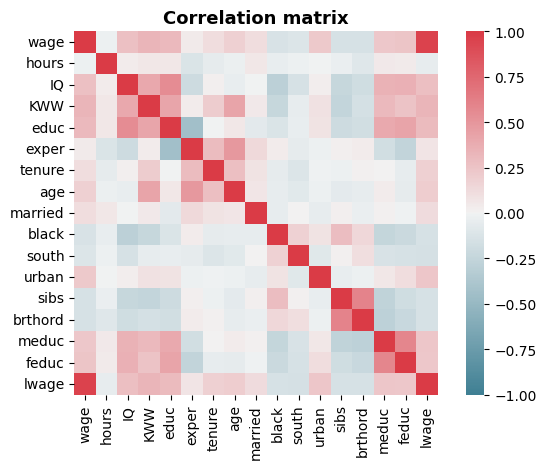

In [272]:
fig,ax=plt.subplots()
variables=['wage','hours','IQ', 'KWW', 'educ', 'exper', 'tenure','age','married','black','south','urban','sibs','brthord','meduc','feduc','lwage']
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(train[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax, cmap=cmap)
ax.set_title('Correlation matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

The correlation heat-map illustrates some strong positive and negative correlations between variables in this dataset. 
- Positive correlations with the response variable wage exist for IQ, KWW, educ, urban. Age, meduc, feduc, and urban also appear to be positively correlated with wage. The strongest positive correlation is with lwage, which is understandable as lwage is natural log of wage. 

- Surprisingly, exper (years of experience) seems to have little to none correlation with wage, while black and south are negatively correlated, aligning with the distribution graphs above.



In [273]:
train[variables].corr().round(2)

,wage,hours,IQ,KWW,educ,exper,tenure,age,married,black,south,urban,sibs,brthord,meduc,feduc,lwage
wage,1.00,-0.02,0.27,0.33,0.31,0.04,0.12,0.18,0.11,-0.14,-0.11,0.22,-0.15,-0.14,0.23,0.25,0.96
hours,-0.02,1.00,0.04,0.06,0.06,-0.12,-0.06,-0.03,0.06,-0.04,-0.02,-0.00,-0.03,-0.10,0.05,0.04,-0.05
IQ,0.27,0.04,1.00,0.40,0.55,-0.20,0.02,-0.04,-0.01,-0.29,-0.14,0.03,-0.24,-0.18,0.35,0.36,0.28
KWW,0.33,0.06,0.40,1.00,0.42,0.03,0.20,0.42,0.05,-0.24,-0.05,0.09,-0.25,-0.16,0.31,0.26,0.33
educ,0.31,0.06,0.55,0.42,1.00,-0.44,-0.00,0.05,-0.07,-0.12,-0.04,0.08,-0.20,-0.18,0.39,0.42,0.30
exper,0.04,-0.12,-0.20,0.03,-0.44,1.00,0.29,0.49,0.13,0.03,-0.06,-0.02,0.02,0.04,-0.18,-0.26,0.07
tenure,0.12,-0.06,0.02,0.20,-0.00,0.29,1.00,0.27,0.08,-0.06,-0.11,-0.01,-0.02,0.02,0.00,-0.05,0.18
age,0.18,-0.03,-0.04,0.42,0.05,0.49,0.27,1.00,0.07,-0.05,-0.08,-0.02,-0.07,-0.05,0.04,-0.06,0.20
married,0.11,0.06,-0.01,0.05,-0.07,0.13,0.08,0.07,1.00,-0.05,0.00,-0.05,0.02,-0.04,0.01,-0.01,0.12
black,-0.14,-0.04,-0.29,-0.24,-0.12,0.03,-0.06,-0.05,-0.05,1.00,0.18,0.08,0.28,0.15,-0.24,-0.21,-0.15


### **d. Scatter plots of all combinations of variables**

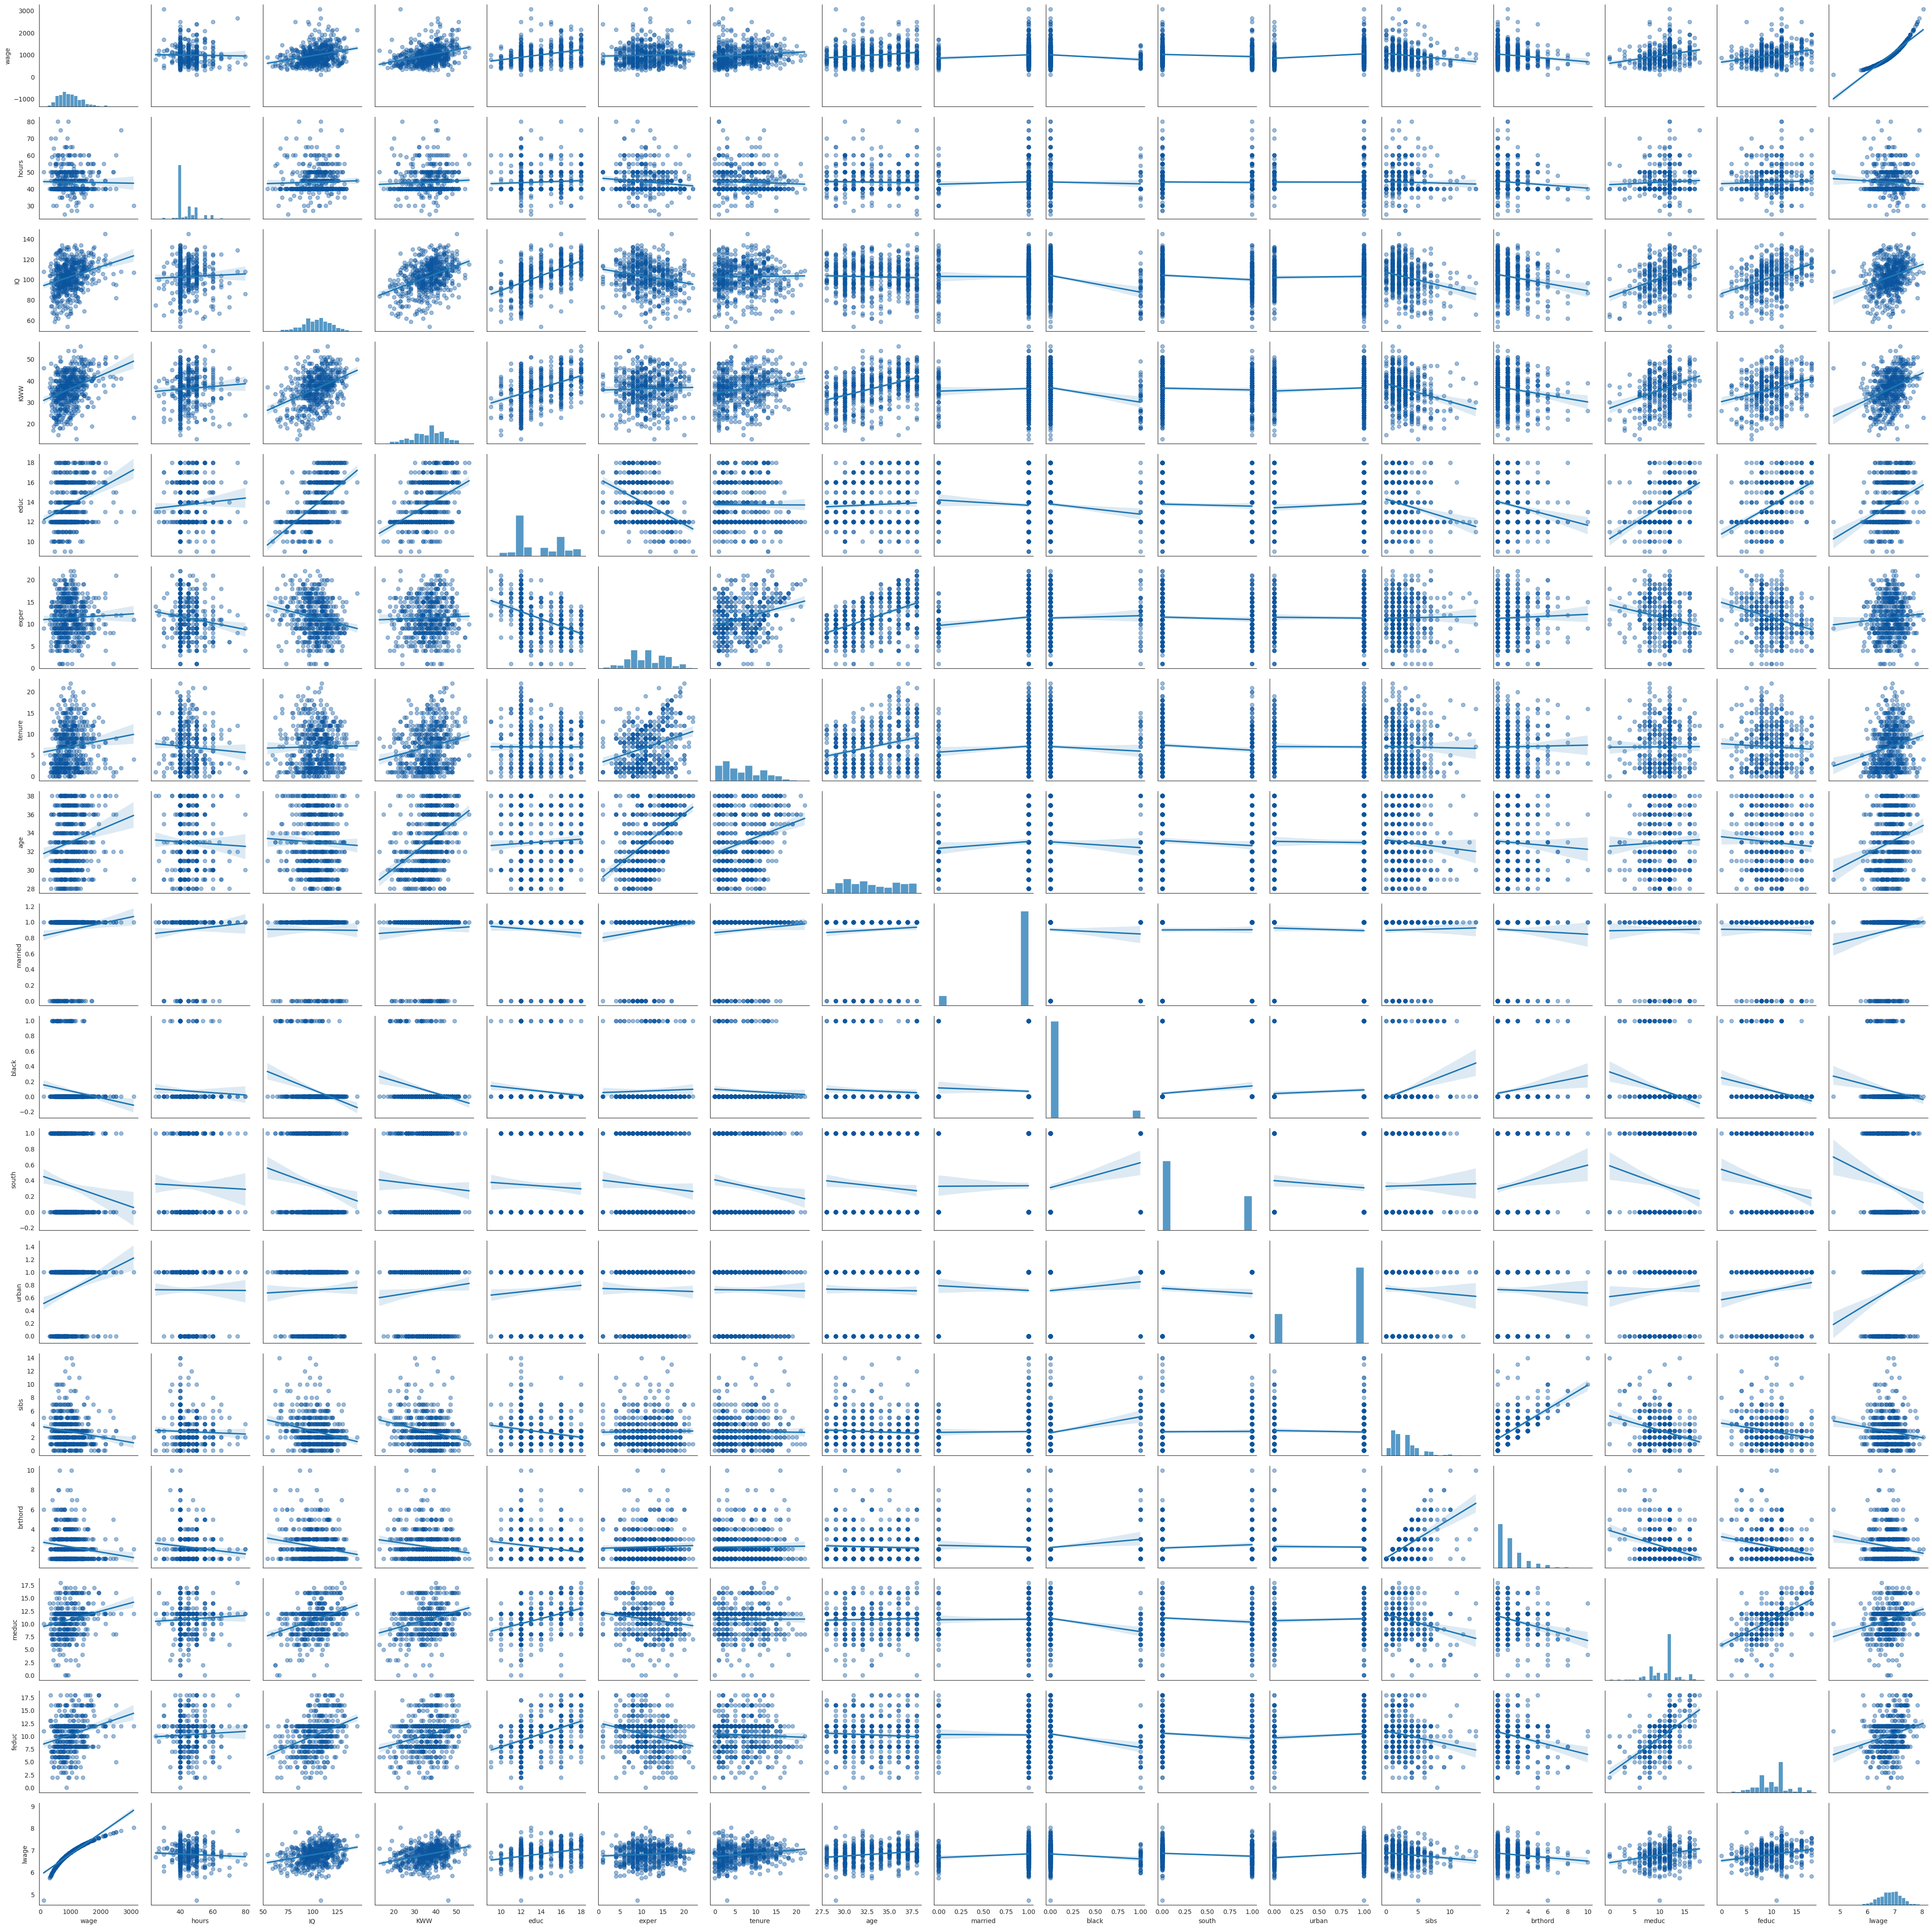

In [274]:
with sns.axes_style('white'):
    g=sns.pairplot(train[variables], kind='reg',
                   plot_kws={'scatter_kws' :{'color': sns.color_palette('Blues')[-1], 'alpha': 0.4}})
plt.tight_layout()
g.savefig('DM-pairplot.png', dpi=300)
plt.show()

Clear positive relationships exist between wage and variables such as IQ, KWW, and education. These relationships appear approximately linear and relatively strong, suggesting these variables may be important predictors in modeling wage. For example, as education increases, average wages also tend to rise, which aligns with economic expectations.

However, some relationships are more complex. The relationship between wage and experience (exper) is initially positive but flattens or even dips slightly at higher levels, indicating a potential non-linear trend. This is also reflected in the plot with tenure and age, where the pattern is less clearly linear and may warrant modeling with squared or interaction terms.

Several categorical variables such as married, black, south, and urban show distinct groupings in wage but with overlapping distributions, implying they may influence wage through interaction effects or differ in variance, rather than in pure mean differences.

Regarding the parental education variables (meduc and feduc), the relationships with wage are present but weak. This suggests background factors may have some influence, though they are not as predictive as an individual's own education or ability (as proxied by IQ and KWW).

In terms of relationships between the predictors, no extremely strong correlations are observed that would suggest problematic multicollinearity. While there are some moderate associations (e.g., between educ and IQ, or tenure and age), none are strong enough to cause immediate concern for variance inflation in the regression model. At this stage, multicollinearity does not appear to be a major issue.

# **Task 2: Analysis of relationship between exper, educ, and wage**

### **a. Data description**

In [275]:
train[['wage','educ','exper']].describe().round(2)  #training data description

,wage,educ,exper
count,531.00,531.00,531.00
mean,995.62,13.73,11.41
std,409.45,2.25,4.26
min,115.00,9.00,1.00
25%,700.00,12.00,8.00
50%,929.00,13.00,11.00
75%,1201.50,16.00,15.00
max,3078.00,18.00,22.00


### **b. Multiple Linear Regression (MLR)**

In [276]:
#Full model MLR (numerical + categorical)

model = smf.ols(formula='wage ~ hours +  IQ + KWW + educ + exper + tenure + age + married + black + south + urban + sibs + brthord + meduc + feduc', data=train)
reg = model.fit()
reg.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.215
Method:                 Least Squares   F-statistic:                     10.70
Date:                Fri, 30 May 2025   Prob (F-statistic):           1.22e-22
Time:                        22:01:05   Log-Likelihood:                -3874.8
No. Observations:                 531   AIC:                             7782.
Df Residuals:                     515   BIC:                             7850.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -594.3412    260.485     -2.282      0.023   -1106.085     -82.597
hours         -2.2238      2.215     -1.004      0.316      -6.576       2.128
IQ             1.9545      1.405      1.391      0.165      -0.807       4.716
KWW            6.6200      2.785      2.377      0.018       1.149      12.091
educ          37.9593     10.413      3.646      0.000      17.503      58.416
exper         12.1049      5.264      2.300      0.022       1.763      22.447
tenure         2.5618      3.434      0.746      0.456      -4.185       9.308
age            5.9827      6.944      0.862      0.389      -7.659      19.625
married      146.8417     54.020      2.718      0.007      40.716     252.968
black        -67.0372     66.932     -1.002      0.317    -198.531      64.457
south        -27.3144     35.273     -0.774      0.439     -96.611      41.982
urban        170.7131     36.030      4.738      0.000      99.929     241.497
sibs           1.5727      9.227      0.170      0.865     -16.555      19.700
brthord      -11.2680     13.480     -0.836      0.404     -37.750      15.214
meduc          3.2926      7.307      0.451      0.652     -11.062      17.648
feduc         11.1663      6.228      1.793      0.074      -1.070      23.402
==============================================================================
Omnibus:                      164.611   Durbin-Watson:                   1.823
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              630.335
Skew:                           1.378   Prob(JB):                    1.33e-137
Kurtosis:                       7.571   Cond. No.                     2.08e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.08e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The effects of each variable can be summarized as:

Keeping all other variables constant, an increase of 1 average weekly hour is associated with an average decrease in the wage of 2.22 dollars.

Keeping all other variables constant, an increase of 1 IQ score is associated with an average increase in the wage of 1.95 dollars.

Keeping all other variables constant, an increase of 1 knowledge of world work score is associated with an average increase in the wage of 6.62 dollars.

Keeping all other variables constant, an increase of 1 year of education is associated with an average increase in the wage of 37.96 dollars.

Keeping all other variables constant, an increase of 1 year of experience is associated with an average increase in the wage of 12.10 dollars.

Keeping all other variables constant, an increase of 1 year with current employer is associated with an average decrease in the wage of 2.56 dollars.

Keeping all other variables constant, an increase of 1 age is associated with an average increase in the wage of 5.98 dollars.

Keeping all other variables constant, married people earns 146.84 dollars on average more than others. 

Keeping all other variables constant, black people earns 67.04 dollars on average less than others. 

Keeping all other variables constant, south people earns 27.31 dollars on average less than others. 

Keeping all other variables constant, urban people earns 170.71 dollars on average more than others. 

Keeping all other variables constant, an increase of 1 sibling is associated with an average increase in the wage of 1.57 dollars.

Keeping all other variables constant, an increase of 1 birth order is associated with an average decrease in the wage of 11.27 dollars.

Keeping all other variables constant, an increase of 1 year of mother's education is associated with an average increase in the wage of 3.29 dollars.

Keeping all other variables constant, an increase of 1 year of father's education is associated with an average increase in the wage of 11.17 dollars.


In [277]:
reg.mse_resid**0.5

np.float64(362.69230272797444)

In [283]:
#Full model MLR (numerical only)

model = smf.ols(formula='wage ~ hours +  IQ + KWW + educ + exper + tenure + age + sibs + brthord + meduc + feduc', data=train)
reg = model.fit()
reg.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.192
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     11.22
Date:                Sat, 31 May 2025   Prob (F-statistic):           8.69e-19
Time:                        08:42:44   Log-Likelihood:                -3890.2
No. Observations:                 531   AIC:                             7804.
Df Residuals:                     519   BIC:                             7856.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -433.6795    255.942     -1.694      0.091    -936.488      69.129
hours         -1.8101      2.265     -0.799      0.425      -6.260       2.640
IQ             2.0560      1.402      1.466      0.143      -0.699       4.811
KWW            8.0310      2.823      2.845      0.005       2.485      13.577
educ          37.5400     10.548      3.559      0.000      16.819      58.261
exper         14.3972      5.364      2.684      0.008       3.859      24.935
tenure         3.0966      3.498      0.885      0.376      -3.775       9.968
age            4.1275      7.083      0.583      0.560      -9.787      18.042
sibs           0.6802      9.176      0.074      0.941     -17.347      18.708
brthord      -12.2056     13.679     -0.892      0.373     -39.079      14.668
meduc          4.0213      7.455      0.539      0.590     -10.625      18.668
feduc         14.5355      6.332      2.295      0.022       2.095      26.976
==============================================================================
Omnibus:                      151.318   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              526.871
Skew:                           1.294   Prob(JB):                    3.90e-115
Kurtosis:                       7.138   Cond. No.                     1.99e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.99e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [279]:
#Reduced model (educ + exper)

model_base = smf.ols(formula='wage ~ educ + exper', data=train) 
regbase = model_base.fit()
regbase.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     41.43
Date:                Fri, 30 May 2025   Prob (F-statistic):           1.93e-17
Time:                        22:02:51   Log-Likelihood:                -3908.1
No. Observations:                 531   AIC:                             7822.
Df Residuals:                     528   BIC:                             7835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -264.3942    142.291     -1.858      0.064    -543.921      15.133
educ          74.1534      8.201      9.042      0.000      58.043      90.263
exper         21.2275      4.323      4.910      0.000      12.735      29.720
==============================================================================
Omnibus:                      135.138   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              389.743
Skew:                           1.220   Prob(JB):                     2.34e-85
Kurtosis:                       6.416   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Similar to the full model, both variables educ and exper are positively related to wage. The effects of each variable can be summarized as:

- Keeping years of work experience constant, an increase of 1 year of education is associated with an average increase in the wage of $74.15$ dollars.
- Keeping years of education constant, an increase of 1 year of experience is associated with an average increase in the wage of $21.23$ dollars.

Noteworthily, the estimated coefficients for educ and exper in the reduced model are significantly different to their respective etimates in the full model (nearly twice the full model's estimation). This could be evidence of some omitted variable bias (OVB) in this reduced model, for both variables. We consider this in more detail in Task 3. 


In [280]:
residbase=regbase.resid
fitbase=regbase.fittedvalues
regbase.mse_resid**0.5

np.float64(381.38333895467906)

In [281]:
train[['educ','exper']].corr()

,educ,exper
educ,1.000000,-0.438547
exper,-0.438547,1.000000


In [282]:
1/(1-(-0.438547**2))

0.8386985781517942

### **c. Measure of fit (reduced model)**

- The full model has $R^2$ = $0.238$, $R^2_{adj}$ = $0.215$ and SER = $362.69$ dollars. This means that it captures about $24\%$ of the variation in wages, with a typical prediction error of about $\$363$.
- The reduced model has $R^2 = 0.136$, $R^2_{adj} = 0.132$ and SER = $375.64$ dollars. This means that it captures about $14\%$ of the variation in wages, with a typical prediction error of about $\$376$. 

Both models are relatively weak fits to the data, but the full model is the strongest fit between the two, capturing about $10$ percentage point more variation in wages and reducing the prediction error by about $\$13$.   

The low values for $R^2$ and $R^2_{adj}$ can mainly be due to weak predictors overall of the model (intuitively sibs, brthord, etc. may have have little real impact on wage) and non-linearity of some of the variables. Therefore, other meaningful predictors should rather be used, and transformations will be further examined in Task 3 and 4. Another concern is with the amount of data we have dropped in the data cleaning process: up to 1/3 of original data. This may cause significant reduction in $R^2$ and $R^2{adj}$. 

The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between educ and exper, as calculated above, equal 0.84. This is not a large number -- the usual threshold for the presence of a multicollinearity problem is 5.


In [284]:
#calculate VIFs for predictors
features=train[['educ','exper']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.238
VIF for exper: 1.238
Average VIF: 1.238


The VIF for educ and exper are 1.238 each, which is well below the common thresholds of 5 or 10. This means that no significant multicollinearity is happnening between educ and exper, making the data much more meaningful.

### **d. Assessment of reduced model's goodness of fit**

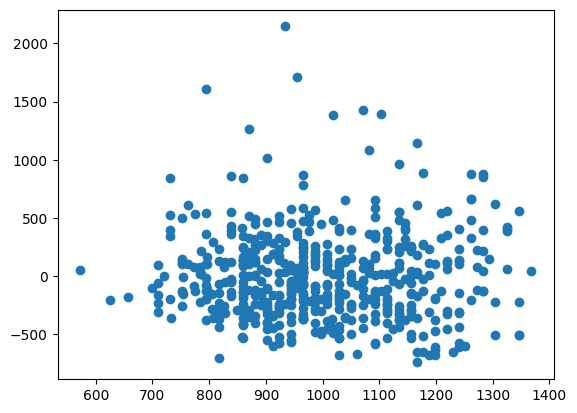

In [285]:
plt.scatter(fitbase,residbase)
plt.show()

/opt/anaconda3/envs/skywalker/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


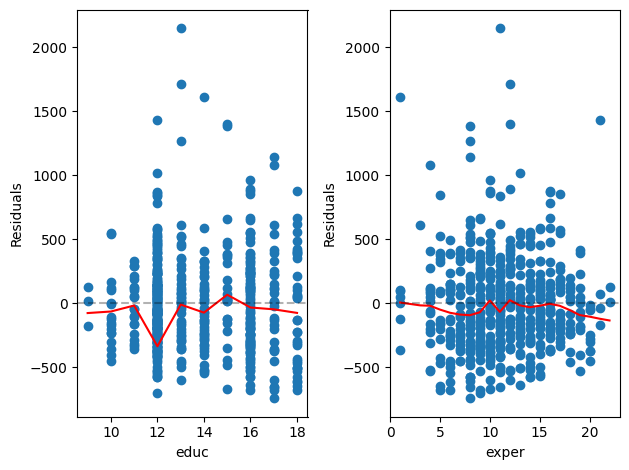

In [286]:

lowess = sm.nonparametric.lowess

fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~regbase.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'], regbase.resid)
z1 = lowess(regbase.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~regbase.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(regbase.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'], regbase.resid)
z2 = lowess(regbase.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

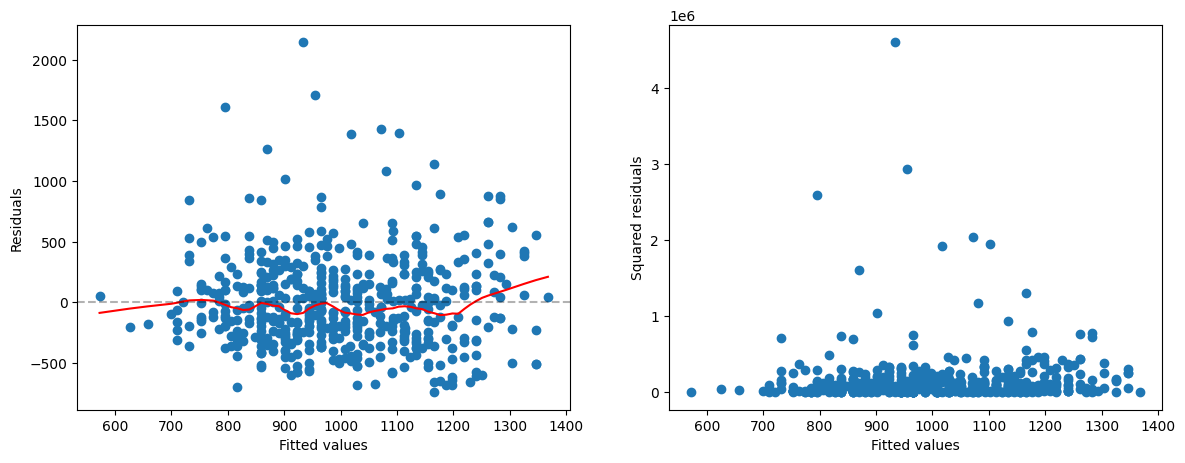

In [287]:
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(regbase.fittedvalues,regbase.resid)
z1=lowess(regbase.resid,regbase.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
residbase2=regbase.resid**2
ax2.scatter(regbase.fittedvalues,residbase2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

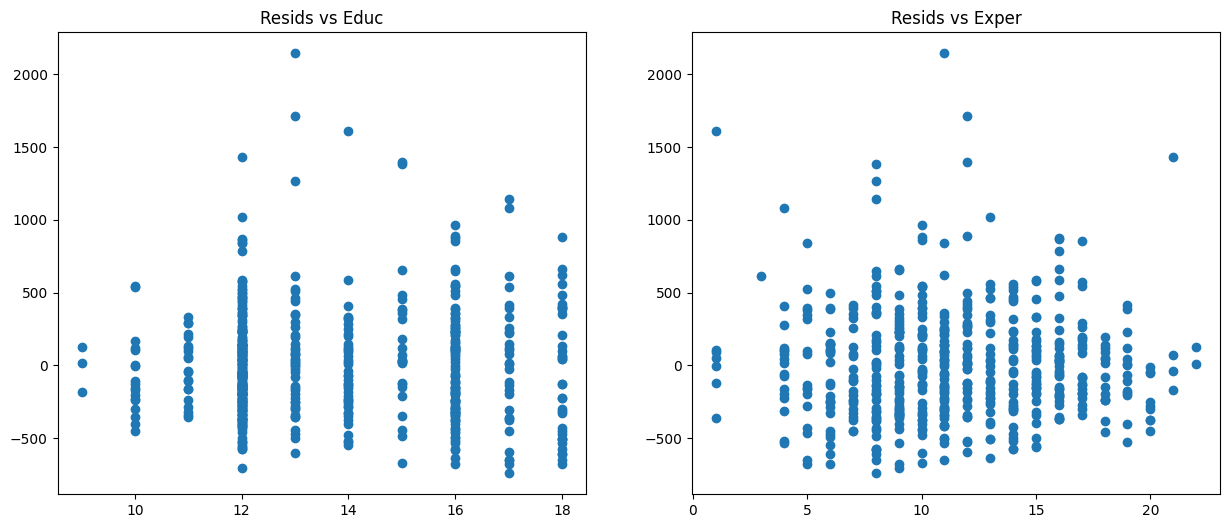

In [290]:
fig = plt.figure(figsize=(15,6))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.scatter(train['educ'],residbase)
ax1.set_title("Resids vs Educ")
ax2.scatter(train['exper'], residbase)
ax2.set_title("Resids vs Exper")
plt.show()

The residuals vs fitted values plot shows no clear pattern in the mean, i.e. the errors seem to average close to 0 for most fitted values, as confirmed by the LOESS curve (apart from a mild dip in the middle). The residuals vs each predictor show that **E**$(e|X) = 0$ appears to hold for most value of $X$. Thus, the linear model seems a reasonable fit for the wage data.

However, there is evidence that the variance of residuals increases slightly for higher fitted values. This is visible in the squared residuals plot, where spread is larger around the middle to the extremes. Hence, the assumption of constant variance may not hold, and inference may benefit from using heteroskedasticity-robust standard errors.

The scatter plots of wage against each predictor (in blue), overlaid with fitted values (in red), offer additional insights:

For **education**, the red predicted values track the increasing trend in wage with rising education, though they tend to underpredict for higher earners.

For **experience**, a similar pattern is observed: predictions follow the general shape of the data but fail to capture some curvature or variance at higher experience levels. These plots suggest that the model captures the main linear trend well, though it might benefit from polynomial or interaction terms for more accuracy. 

Regarding the other MLR LSA:

**LSA 2** requires **E**$(e|X) = 0$. While the residual plots support this assumption, it may still be violated due to **omitted variable bias**. For instance, IQ and KWW, which show a positive correlation with wage and likely correlate with educ, are not included in this model. This may bias the coefficient estimates for educ. We cover this more in Task 3.

**LSA 3** assumes that the observations are i.i.d. As we lack temporal or cluster structure in the data, we proceed under this assumption.

**LSA 4** concerns finite $4^{th}$ moments. Variables such as exper, educ and wage are bounded in practice and show no severe outliers, so this assumption is reasonably satisfied. 

**LSA 5** (no perfect multicollinearity): educ and exper and only moderately correlated (~ -0.44), which is well below the threshold for concern. We tested this again using VIF, and the result cemented the previous argument. Hence, no standout multicollinearity issues are detected. 

### **e. Interaction effect between educ and exper**

In [291]:
task2interact = smf.ols('wage ~ educ + exper + educ:exper', data = train).fit()
print(task2interact.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     30.24
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.76e-18
Time:                        08:59:31   Log-Likelihood:                -3904.7
No. Observations:                 531   AIC:                             7817.
Df Residuals:                     527   BIC:                             7834.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    494.5601    321.511      1.538      0.1

Compared to the reduced model (consisting of educ and exper only), this model that includes the interaction effect produced a higher $R^2$ and $R^2_{adj}$. The model without interaction effect has adjusted $R^2$ of $0.132$ while that of the new model is $0.142$, slightly better. 

Notably, the p-value for the interaction effect between educ and exper here is statistically significant with $0.009 < 0.05$ (chosen alpha), allowing us to reject the hypothesis that the interaction between these 2 variables has no effect on wage. 

This suggests that the effect of education on wage depends on the level of education, and vice versa.

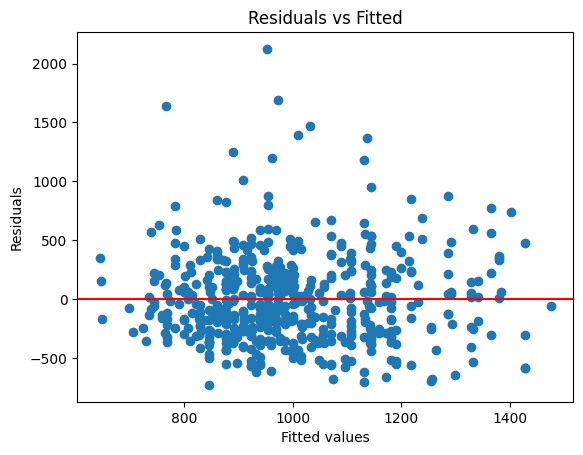

In [292]:
fitted_vals = task2interact.fittedvalues
residuals = task2interact.resid

plt.scatter(fitted_vals, residuals)
plt.axhline(y=0, color='red')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

The residuals vs. fitted values plot shows no visible signs of heteroskedasticity apart from several outliers in the middle; therefore, we can assume LSA 6 (homoskedasticity) holds in this model.

# **Task 3: Omitted Variable Bias**

### **a. Discussion of possible variables that can cause OVB**

### Reduced model with educ and exper

In [293]:

model_base = smf.ols(formula='wage ~ educ + exper', data=train) 
regbase = model_base.fit()
regbase.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     41.43
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.93e-17
Time:                        09:01:35   Log-Likelihood:                -3908.1
No. Observations:                 531   AIC:                             7822.
Df Residuals:                     528   BIC:                             7835.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -264.3942    142.291     -1.858      0.064    -543.921      15.133
educ          74.1534      8.201      9.042      0.000      58.043      90.263
exper         21.2275      4.323      4.910      0.000      12.735      29.720
==============================================================================
Omnibus:                      135.138   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              389.743
Skew:                           1.220   Prob(JB):                     2.34e-85
Kurtosis:                       6.416   Cond. No.                         155.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Discussion of possible OVB causes

The variable KWW appears to be the most likely determinant of an individual's wage since it has the highest positive correlation with wage out of all other variables ($r = 0.42$). KWW is also intuitively logical as individuals with higher levels of education are likely to score higher on knowledge-based assessments. 

IQ also seems like a reasonable choice, as it may be related to years of education and work experience. It is also positively correlated with wage and educ ($r$ = $0.27$ and $0.55$ respectively) while negatively related to years of experience with correlation of -$0.20$.

Mother education (meduc) is also a possible cause, as individuals whose mothers have higher educations are more likely to attain higher education themselves, due to family backgrounds, values, and resources. 


Looking at the full model, the urban variable also shows a p-value of $0.000$ < $0.05$ (chosen alpha), making it a good choice for testing OVB. Intuitively, people who live in urban areas are also introduced to more opportunities. 

Tenure (years with current employees), however, may seem like a good cause for OVB but is also likely to cause multicollinearity as it is too similar to exper. We will discuss this later.

In summary, this report will include IQ, KWW, urban and meduc to check for omitted variable bias. 

In [294]:
newmodel = smf.ols(formula='wage ~ educ + exper + urban + meduc + IQ + KWW', data=train)
newreg = newmodel.fit()
newreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.204
Method:                 Least Squares   F-statistic:                     23.57
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.05e-24
Time:                        09:02:42   Log-Likelihood:                -3883.4
No. Observations:                 531   AIC:                             7781.
Df Residuals:                     524   BIC:                             7811.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -566.1906    152.348     -3.716      0.000    -865.479    -266.903
educ          40.6097      9.962      4.076      0.000      21.038      60.181
exper         16.5325      4.301      3.844      0.000       8.084      24.981
urban        166.8135     35.583      4.688      0.000      96.912     236.716
meduc         12.6047      6.325      1.993      0.047       0.180      25.029
IQ             2.4373      1.330      1.832      0.068      -0.176       5.051
KWW            8.4509      2.485      3.401      0.001       3.569      13.333
==============================================================================
Omnibus:                      154.505   Durbin-Watson:                   1.795
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              562.093
Skew:                           1.306   Prob(JB):                    8.77e-123
Kurtosis:                       7.311   Cond. No.                     1.08e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.08e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

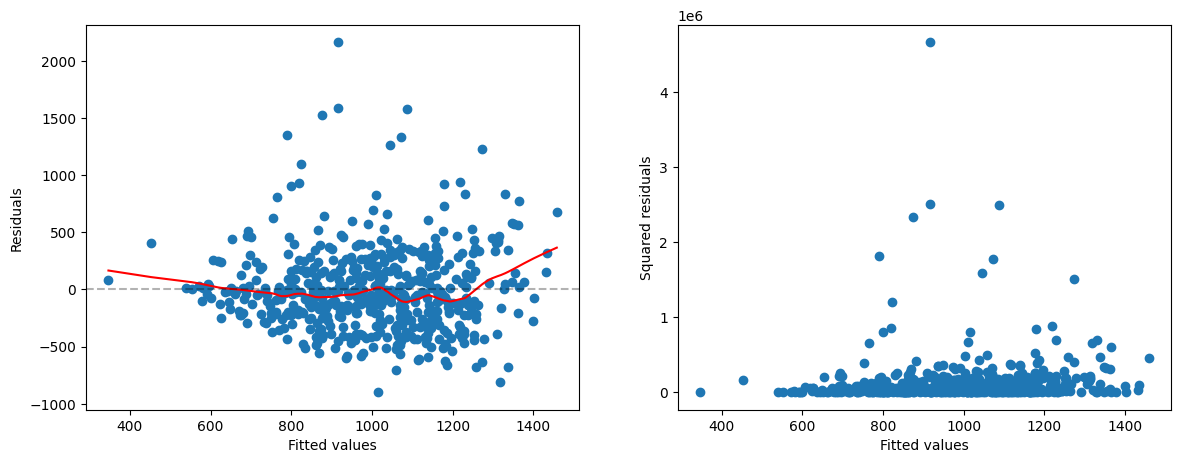

In [295]:
#Residual and squared residual plots against fitted values
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(newreg.fittedvalues,newreg.resid)
z1=lowess(newreg.resid,newreg.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
newreg2=newreg.resid**2
ax2.scatter(newreg.fittedvalues,newreg2)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

In [296]:
newresid=newreg.resid
newfit=newreg.fittedvalues
newreg.mse_resid**0.5

np.float64(365.415353346777)

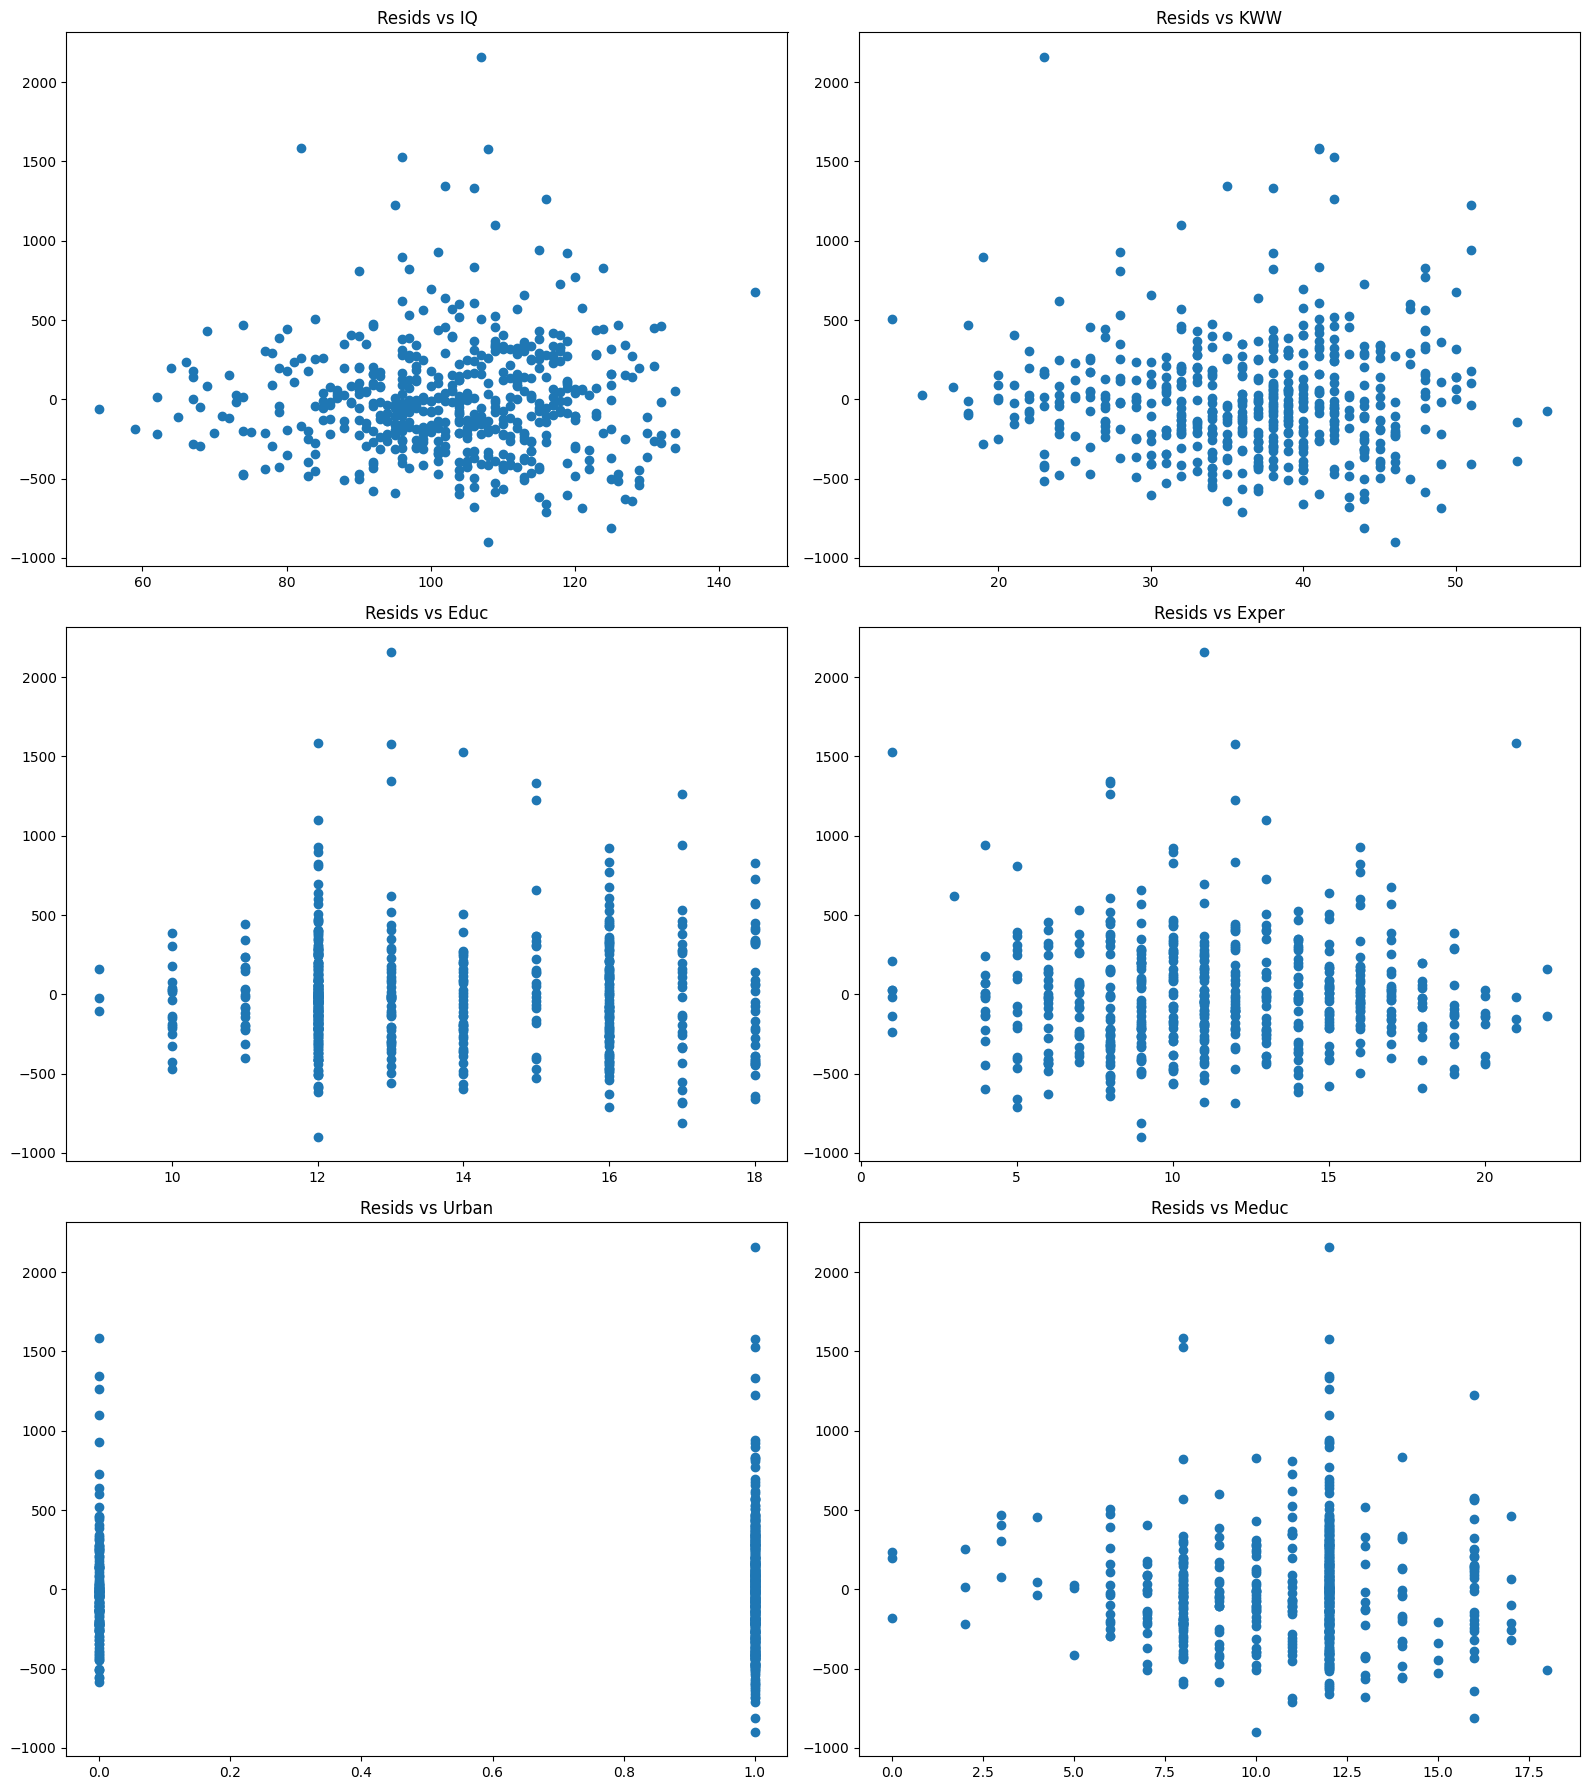

In [297]:
fig, ax = plt.subplots(3, 2, figsize=(16, 18))  # 6 plots, no empty slots

ax[0,0].scatter(train['IQ'], newresid)
ax[0,0].set_title("Resids vs IQ")

ax[0,1].scatter(train['KWW'], newresid)
ax[0,1].set_title("Resids vs KWW")

ax[1,0].scatter(train['educ'], newresid)
ax[1,0].set_title("Resids vs Educ")

ax[1,1].scatter(train['exper'], newresid)
ax[1,1].set_title("Resids vs Exper")

ax[2,0].scatter(train['urban'], newresid)
ax[2,0].set_title("Resids vs Urban")

ax[2,1].scatter(train['meduc'], newresid)
ax[2,1].set_title("Resids vs Meduc")

plt.tight_layout()
plt.show()

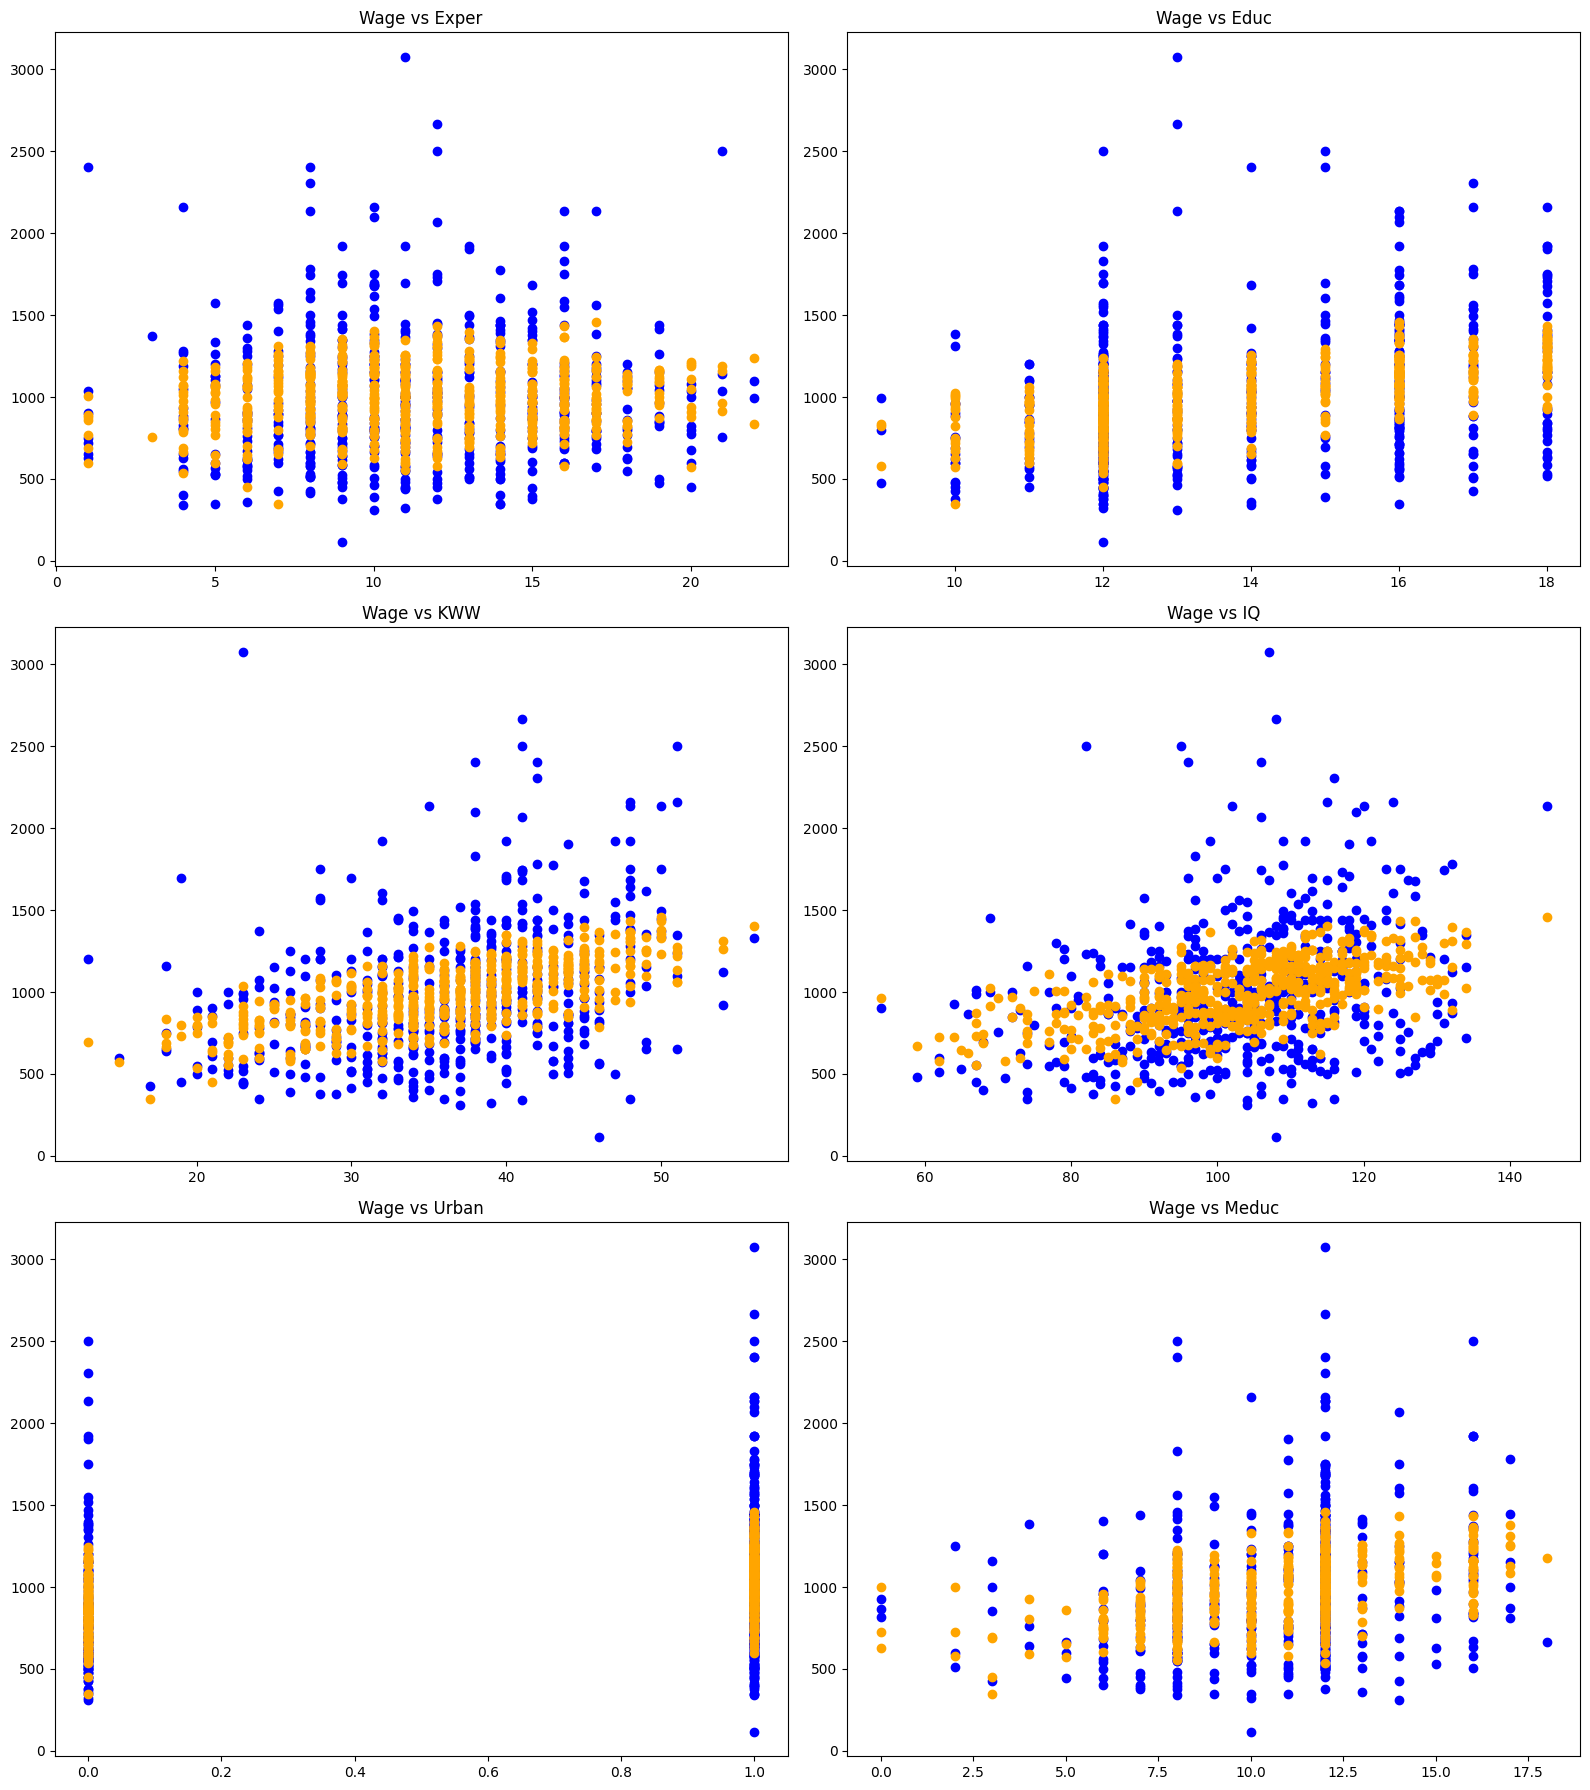

In [298]:
fig, ax = plt.subplots(3, 2, figsize=(16, 18))

ax[0,0].scatter(train['exper'], train['wage'], c='blue')
ax[0,0].scatter(train['exper'], newfit, c='orange')
ax[0,0].set_title("Wage vs Exper")

ax[0,1].scatter(train['educ'], train['wage'], c='blue')
ax[0,1].scatter(train['educ'], newfit, c='orange')
ax[0,1].set_title("Wage vs Educ")

ax[1,0].scatter(train['KWW'], train['wage'], c='blue')
ax[1,0].scatter(train['KWW'], newfit, c='orange')
ax[1,0].set_title("Wage vs KWW")

ax[1,1].scatter(train['IQ'], train['wage'], c='blue')
ax[1,1].scatter(train['IQ'], newfit, c='orange')
ax[1,1].set_title("Wage vs IQ")

ax[2,0].scatter(train['urban'], train['wage'], c='blue')
ax[2,0].scatter(train['urban'], newfit, c='orange')
ax[2,0].set_title("Wage vs Urban")

ax[2,1].scatter(train['meduc'], train['wage'], c='blue')
ax[2,1].scatter(train['meduc'], newfit, c='orange')
ax[2,1].set_title("Wage vs Meduc")

plt.tight_layout()
plt.show()

/opt/anaconda3/envs/skywalker/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


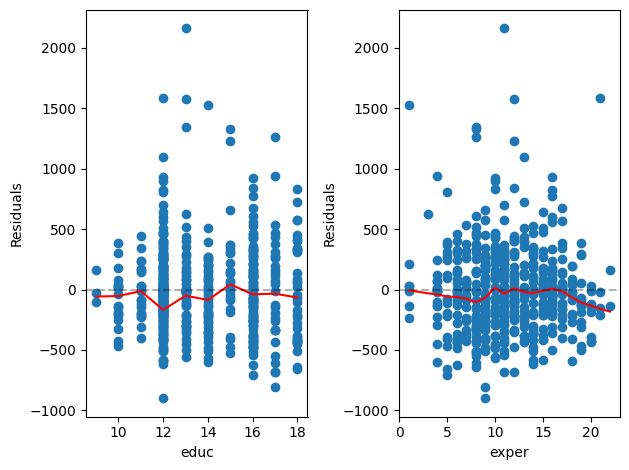

In [299]:
fig = plt.figure()
ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2)

# First plot (educ vs residuals)
mask1 = (
    ~newreg.resid.isna() & 
    ~train['educ'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['educ'])
)
ax1.scatter(train['educ'][mask1], newreg.resid[mask1])
z1 = lowess(newreg.resid[mask1], train['educ'][mask1], frac=1./5)
ax1.plot(z1[:, 0], z1[:, 1], 'red')
ax1.set_xlabel('educ')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black', alpha=0.3, linestyle='--')

# Second plot (exper vs residuals)
mask2 = (
    ~newreg.resid.isna() & 
    ~train['exper'].isna() & 
    np.isfinite(newreg.resid) & 
    np.isfinite(train['exper'])
)
ax2.scatter(train['exper'][mask2], newreg.resid[mask2])
z2 = lowess(newreg.resid[mask2], train['exper'][mask2], frac=1./5)
ax2.plot(z2[:, 0], z2[:, 1], 'red')
ax2.set_xlabel('exper')
ax2.set_ylabel('Residuals')
ax2.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

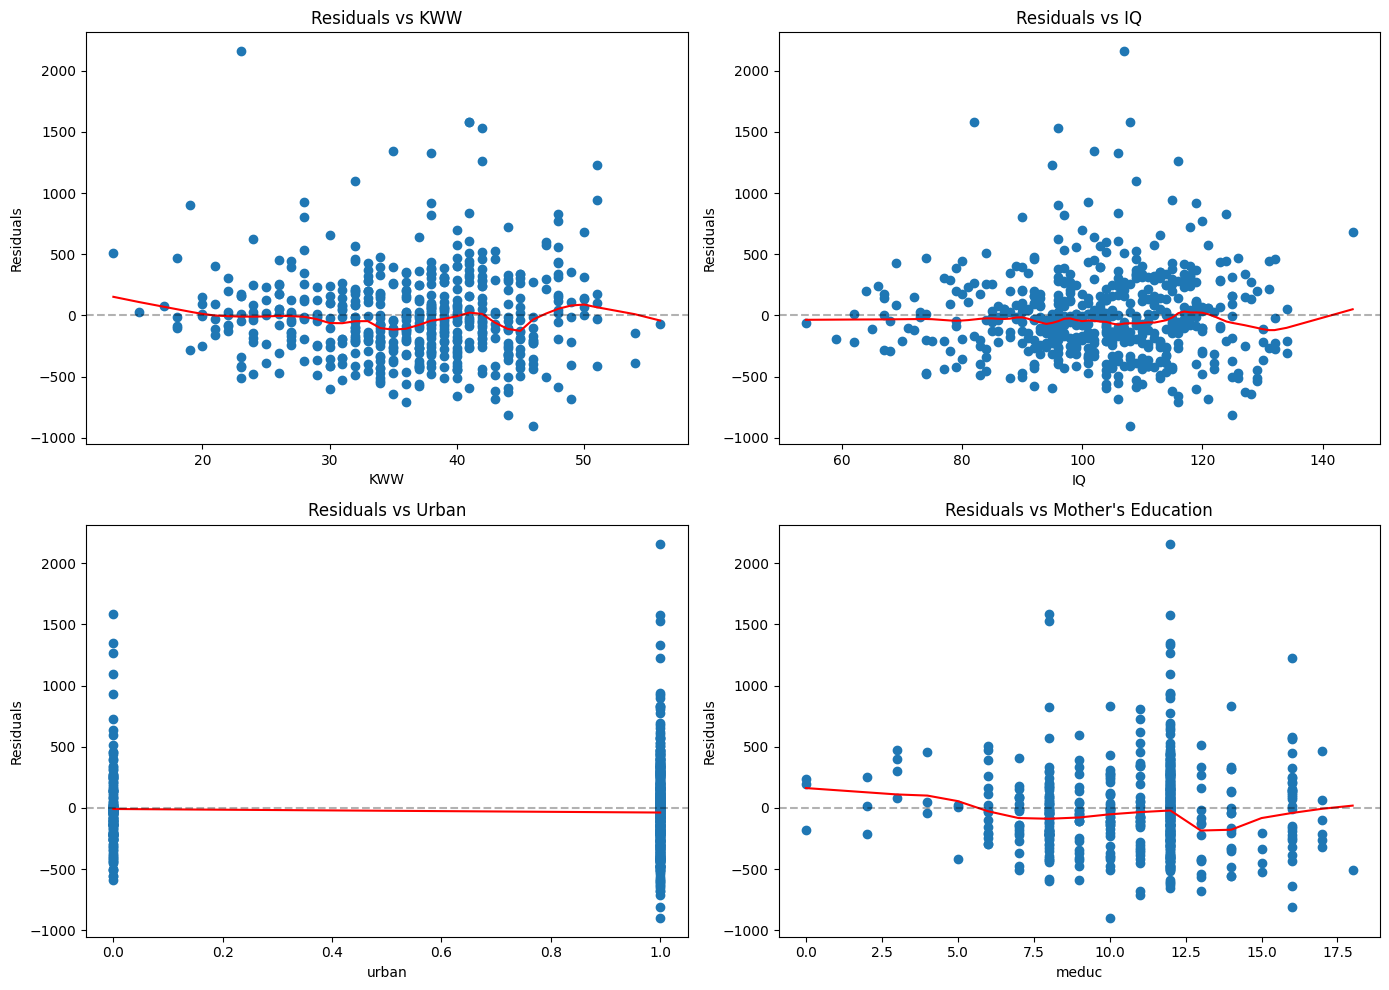

In [300]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['KWW', 'IQ', 'urban', 'meduc']
titles = ['KWW', 'IQ', 'Urban', 'Mother\'s Education']

for ax, var, title in zip(axes.flatten(), variables, titles):
    mask = (
        ~newreg.resid.isna() &
        ~train[var].isna() &
        np.isfinite(newreg.resid) &
        np.isfinite(train[var])
    )
    ax.scatter(train[var][mask], newreg.resid[mask])
    z = lowess(newreg.resid[mask], train[var][mask], frac=1./5)
    ax.plot(z[:, 0], z[:, 1], 'red')
    ax.set_xlabel(var)
    ax.set_ylabel('Residuals')
    ax.set_title(f'Residuals vs {title}')
    ax.axhline(color='Black', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

The original reduced multiple linear regression (MLR) model was estimated as:

$$
\hat{Wage} = -264.39 + 74.15 \times \text{educ} + 21.23 \times \text{exper}
$$

The 95% confidence intervals for the two slopes are:
- **educ**: $(58.04, 90.26)$
- **exper**: $(12.74, 29.72)$

---

The new MLR model (with KWW, IQ, urban, meduc included) is estimated as:

$$
\hat{Wage} = -566.19 + 40.61 \times \text{educ} + 16.53 \times  
\text{exper} + 8.45 \times \text{KWW} + 166.81 \times \text{urban} + 2.44 \times \text{IQ} + 12.60 \times \text{Meduc}
$$

The 95% confidence intervals for the three slopes are:
- **IQ**: $(-0.176, 5.051)$
- **KWW**: $(3.569, 13.333)$
- **urban**: $(96.912, 236.716)$
- **meduc**: $(0.180, 25.029)$
- **educ**: $(21.038, 60.181)$
- **exper**: $(8.084, 24.981)$

---

The estimated effect of **educ** in the three-variable MLR has dropped below the 95% confidence interval from the two-variable MLR. This suggests that **all chosen suspected variables were causing omitted variable bias (OVB)** in the original estimate of education’s effect on wage.

The estimated effect of **exper** has become slightly more negative in the three-variable model. However, the $95%$ confidence intervals from both models overlap substantially. This implies the difference in estimates could be due to **estimation error rather than OVB**.

However, the p-value could be examined to look at the effects of these variables. The standout is p-value of $0.068$ for IQ, suggesting that we cannot reject the hypothesis that it does not affect wage. meduc is also only mildly smaller than the chosen alpha $(0.047< 0.05)$, making its impact questionable. Nevertheless, all other variables have p-value of near $0$, indicating that they might be the cause for OVB here. 

In summary, while the inclusion of all chosen suspected variables reveal likely OVB in the estimate of **educ**, the **large standard errors** make it difficult to precisely quantify how much bias was introduced — or if the bias in **exper** was meaningful at all.


### **b. Test for relationships between wage, exper, educ**

### Correlation matrix 

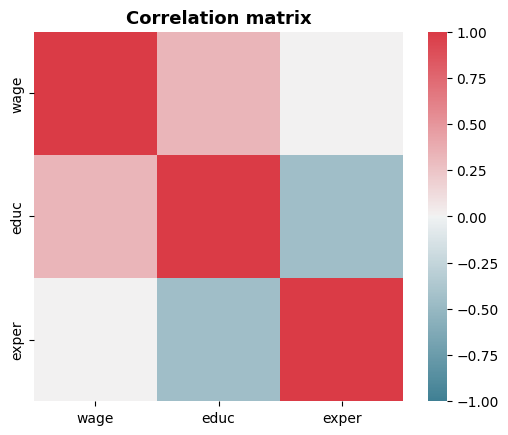

In [301]:
fig_wee, ax_wee = plt.subplots()
variables = ['wage', 'educ', 'exper']
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(data[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax_wee, cmap=cmap)
ax_wee.set_title('Correlation matrix', fontweight='bold', fontsize=13)


plt.show()

In [302]:
train[['educ', 'exper', 'wage']].corr().round(2)


,educ,exper,wage
educ,1.00,-0.44,0.31
exper,-0.44,1.00,0.04
wage,0.31,0.04,1.00


There are some clear correlations between wage and educ, wage and exper. For wage and educ, they have a positive correlation with $r = 0.31$, while that between wage and exper is $0.04$ meaning little to no real impact. Interestingly, exper and educ are highly correlated, with $r = -0.44$, making it the highest negative correlation between 2 variables. 

### OLS between wage and exper, wage and educ

In [303]:
model_task3_educ = smf.ols(formula='wage ~ educ', data=train) 
reg_task3_educ = model_task3_educ.fit()
reg_task3_educ.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     56.30
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.65e-13
Time:                        09:05:51   Log-Likelihood:                -3920.0
No. Observations:                 531   AIC:                             7844.
Df Residuals:                     529   BIC:                             7852.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    220.2444    104.714      2.103      0.036      14.538     425.951
educ          56.4936      7.529      7.503      0.000      41.703      71.285
==============================================================================
Omnibus:                      116.748   Durbin-Watson:                   1.869
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              294.467
Skew:                           1.103   Prob(JB):                     1.14e-64
Kurtosis:                       5.905   Cond. No.                         86.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The $R^2$ and $R^2_{adj}$ for predicting wage using years of education is $0.096$ and $0.094$ respectively, suggesting that around 10% of the variation in wage can be explained using only years of education. This is a quite high number, and the extremely low of p-value for educ suggests that educ is indeed necessary in predicting wage.

In [304]:
model_task3_exper = smf.ols(formula='wage ~ exper', data=train) 
reg_task3_exper = model_task3_exper.fit()
reg_task3_exper.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9591
Date:                Sat, 31 May 2025   Prob (F-statistic):              0.328
Time:                        09:08:07   Log-Likelihood:                -3946.3
No. Observations:                 531   AIC:                             7897.
Df Residuals:                     529   BIC:                             7905.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    949.0028     50.811     18.677      0.000     849.187    1048.818
exper          4.0849      4.171      0.979      0.328      -4.109      12.279
==============================================================================
Omnibus:                      114.554   Durbin-Watson:                   1.903
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              239.149
Skew:                           1.165   Prob(JB):                     1.17e-52
Kurtosis:                       5.319   Cond. No.                         35.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In contrast to educ, exper seems to have no relationship with wage. The $R^2$ and $R^2_{adj}$ for OLS between wage and exper is only $0.002$ and -$0.000$, which is very low and is not statistically significant. The p-value of exper further confirms this as it stands at $0.328$. 

Overall, we can conclude that at significance level of $0.05$, there is a relationship between wage and years of education but none between wage and years of experience. However, we realize that this could be due to the the large amount of data dropped during the data cleaning process, causing data distortion. It is also noteworthy that while using the predictive models may rule out years of experience as statistically insignificant, exper remains one of the most important factor that can cause wage changes (intuitively speaking).

### **c. LSAs discussions**

The residuals vs fitted values plot shows that residuals are generally centered around zero, supporting the asusmption that $E(\epsilon|X) = 0$. 
- The LOESS curve remains mostly flat, with no strong curvature, indicating that the linear functional form is reasonable approximation. 
- However, residual spread appears to increase at higher fitted values and around the middle, suggesting potential heteroskedasticity. The squared residual plot supports this, with some outliers in the middle. Therefore, standard errors may benefit from heteroskedasticity-robust correction. 

The scatter plots of wage against each predictor, overlaid with fitted values (in orange), show that the linear model captures the main trends effectively. For education, predictions track the positive relationship with wage, though underprediction may occur for higher education levels. For experience, a similar trend is observed, but the wage gain appears to plateau. Including $exper^2$ in a later model may better capture this curvature. For IQ and KWW, the relationship is linear and strong, while $meduc$ shows a weaker but positive association.

Regarding the other MLR assumptions:

**LSA 2** (Zero conditional mean): The residual plots support this assumption. Furthermore, including $IQ$ and $meduc$ helps reduce omitted variable bias from unobserved ability and family background that influence both education and wage. Their inclusion is supported by both theory and correlation structure.

**LSA 3** (i.i.d. errors): The data is cross-sectional and lacks clustering or time structure, so this assumption is reasonably satisfied.

**LSA 4** (Finite $4^{th}$ moments): Visual inspection of residual shows some outliers but no severe skewness or heavy tails. Predictors such as $IQ$ and $meduc$ are bounded and roughly symmetric. Thus, this assumption is likely to hold.

**LSA 5** (No perfect multicollinearity): The correlation between $educ$ and $meduc$ is moderate ($0.39$), and between $IQ$ and $educ$ ($0.55$), which are acceptable. VIF values are not excessively high (detailed description below), so multicollinearity does not pose a major concern.

In conclusion, the reduced OVB model with $IQ$, $meduc$, $KWW$, $urban$ addresses key sources of bias and satisfies the main LSA conditions. While heteroskedasticity is present, it can be mitigated through robust standard errors. The model fits the data reasonably well and is appropriate for inference. 


### **d. Multicollinearity discussion**

In [305]:
#calculate VIFs for predictors
features=train[['educ','exper','IQ','KWW', 'urban', 'meduc']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 1.990
VIF for exper: 1.335
VIF for IQ: 1.533
VIF for KWW: 1.402
VIF for urban: 1.012
VIF for meduc: 1.246
Average VIF: 1.420


The variance inflation can be measured by the $R^2$ in the regression of one regressor on the other. Both equal to $\frac{1}{1-r^2}$, where $r$ is the correlation between two variables, as calculated above, equal around 1. 

The threshold for these are usually set at 10, and all of the calculated VIFs are well below that number, indicating no perfect multicollinearity in this model.

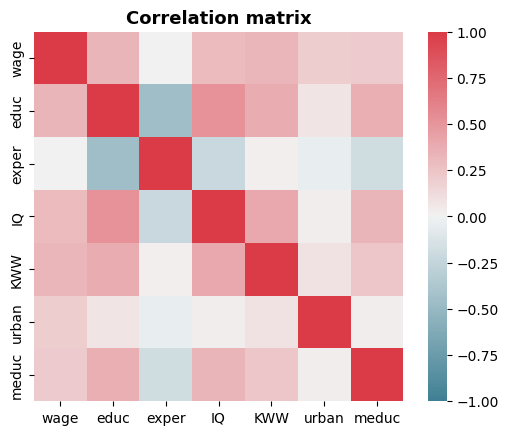

In [306]:
fig_ovb, ax_ovb = plt.subplots()
variables = ['wage', 'educ', 'exper', 'IQ', 'KWW', 'urban', 'meduc']
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(data[variables].corr(), vmax=1, vmin=-1, center=0, square=True, ax=ax_ovb, cmap=cmap)
ax_ovb.set_title('Correlation matrix', fontweight='bold', fontsize=13)


plt.show()

The correlation matrix between these variables, however, is quite interesting as they show some significant correlation between variables such as age vs exper. We will discuss more about this when we perform model and variable selection. 

# **Task 4: Model and variable selection**

## **All proposed transformation**

In [307]:
train_drop = train.drop(columns=['wage'])    # Dropping the 'wage' column
train_drop_lwage = train.drop(columns=['lwage'])  # Dropping the 'lwage' column


# All log transformations (educ, exper, tenure, age, hours)
train_drop['log_educ'] = np.log(train['educ'])
train_drop['log_exper'] = np.log(train['exper'] + 1)
train_drop['log_tenure'] = np.log(train['tenure'] + 1)
train_drop['log_age'] = np.log(train['age'])
train_drop['log_hours'] = np.log(train['hours'] + 1)


test['log_educ'] = np.log(test['educ'])
test['log_exper'] = np.log(test['exper'] + 1)
test['log_tenure'] = np.log(test['tenure'] + 1)
test['log_age'] = np.log(test['age'])
test['log_hours'] = np.log(test['hours'] + 1)


#All power transformations 
train_drop['sqrt_hours'] = np.sqrt(train['hours'])
train_drop['educ2'] = train['educ'] ** 2
train_drop['exper2'] = train['exper'] ** 2

test['sqrt_hours'] = np.sqrt(test['hours'])
test['educ2'] = test['educ'] ** 2
test['exper2'] = test['exper'] ** 2


#All interaction terms 
train_drop['educ_exper'] = train['educ'] * train['exper']
train_drop['IQ_educ'] = train['IQ'] * train['educ']
train_drop['KWW_educ'] = train['KWW'] * train['educ']
train_drop['urban_educ'] = train['urban'] * train['educ']
train_drop['tenure_exper'] = train['tenure'] * train['exper']
train_drop['age_IQ'] = train['age'] * train['IQ']
train_drop['age_educ'] = train['age'] * train['educ']

test['educ_exper'] = test['educ'] * test['exper']
test['IQ_educ'] = test['IQ'] * test['educ']
test['KWW_educ'] = test['KWW'] * test['educ']
test['urban_educ'] = test['urban'] * test['educ']
test['tenure_exper'] = test['tenure'] * test['exper']
test['age_IQ'] = test['age'] * test['IQ']
test['age_educ'] = test['age'] * test['educ']


#All splines (age at 35, educ at 15, tenure at 5)
train_drop['Step_age_35'] = (train['age'] > 35) * (train['age'] - 35)
train_drop['Step_educ_15'] = (train['educ'] > 15) * (train['educ'] - 15)
train_drop['Step_tenure_5'] = (train['tenure'] > 5) * (train['tenure'] - 5)

test['Step_age_35'] = (test['age'] > 35) * (test['age'] - 35)
test['Step_educ_15'] = (test['educ'] > 15) * (test['educ'] - 15)
test['Step_tenure_5'] = (test['tenure'] > 5) * (test['tenure'] - 5)





### **Forward selection**

In [308]:

from forward_selection import forward_selected

candidate_vars = [
    'lwage', 'hours', 'IQ', 'KWW', 'educ', 'exper', 'tenure', 'age', 'sibs', 'brthord',
    'meduc', 'feduc', 'married', 'black', 'south', 'urban',
    'log_educ', 'log_exper', 'log_tenure', 'log_age', 'log_hours',
    'educ_exper', 'IQ_educ', 'KWW_educ', 'urban_educ',
    'tenure_exper', 'age_IQ', 'age_educ',
    'sqrt_hours', 'educ2', 'exper2',
    'Step_age_35', 'Step_educ_15'
]

check_var = forward_selected(
    train_drop[candidate_vars],
    response='lwage',
    nominated=[]
)


adding KWW_educ increases adj_r2 from 0.000000 to 0.145054
adding urban increases adj_r2 from 0.145054 to 0.184251
adding educ_exper increases adj_r2 from 0.184251 to 0.215452
adding married increases adj_r2 from 0.215452 to 0.227415
adding south increases adj_r2 from 0.227415 to 0.236430
adding log_tenure increases adj_r2 from 0.236430 to 0.243638
adding feduc increases adj_r2 from 0.243638 to 0.250707
adding log_exper increases adj_r2 from 0.250707 to 0.254995
adding log_hours increases adj_r2 from 0.254995 to 0.258263
adding IQ increases adj_r2 from 0.258263 to 0.261327
adding Step_educ_15 increases adj_r2 from 0.261327 to 0.262904
adding KWW increases adj_r2 from 0.262904 to 0.264418
adding educ increases adj_r2 from 0.264418 to 0.267037
adding black increases adj_r2 from 0.267037 to 0.269356
adding meduc increases adj_r2 from 0.269356 to 0.270471
adding brthord increases adj_r2 from 0.270471 to 0.270705
adding sqrt_hours increases adj_r2 from 0.270705 to 0.270755
final model is lw

### **Backward selection**

In [309]:
from backward_selection import backward_selected

candidate_vars = [
    'lwage', 'hours', 'IQ', 'KWW', 'educ', 'exper', 'tenure', 'age', 'sibs', 'brthord',
    'meduc', 'feduc', 'married', 'black', 'south', 'urban',
    'log_educ', 'log_exper', 'log_tenure', 'log_age', 'log_hours',
    'educ_exper', 'IQ_educ', 'KWW_educ', 'urban_educ',
    'tenure_exper', 'age_IQ', 'age_educ',
    'sqrt_hours', 'educ2', 'exper2',
    'Step_age_35', 'Step_educ_15'
]

check_var_backward = backward_selected(
    train_drop[candidate_vars],
    response='lwage',
    nominated=[]
)

adj_r2 if all variables included: 0.256295
deleting sqrt_hours increases adj_r2 from 0.256295 to 0.257785
deleting urban increases adj_r2 from 0.257785 to 0.259262
deleting tenure increases adj_r2 from 0.259262 to 0.260708
deleting age_IQ increases adj_r2 from 0.260708 to 0.262039
deleting Step_age_35 increases adj_r2 from 0.262039 to 0.263245
deleting log_age increases adj_r2 from 0.263245 to 0.264662
deleting IQ_educ increases adj_r2 from 0.264662 to 0.265697
deleting log_educ increases adj_r2 from 0.265697 to 0.266653
deleting educ2 increases adj_r2 from 0.266653 to 0.268087
deleting tenure_exper increases adj_r2 from 0.268087 to 0.268889
deleting educ_exper increases adj_r2 from 0.268889 to 0.269602
deleting sibs increases adj_r2 from 0.269602 to 0.270092
deleting hours increases adj_r2 from 0.270092 to 0.270277
final model is lwage ~ age + log_hours + feduc + log_exper + brthord + meduc + exper + log_tenure + urban_educ + Step_educ_15 + educ + exper2 + married + black + south + ag

## **Base model includes: educ + exper + IQ + meduc**

##  **Model 1: base model + urban**

In [310]:
model1 = 'lwage ~ educ + exper + IQ + meduc + urban'
model1 = smf.ols(formula=model1, data=train).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     28.94
Date:                Sat, 31 May 2025   Prob (F-statistic):           5.83e-26
Time:                        09:30:28   Log-Likelihood:                -214.76
No. Observations:                 531   AIC:                             441.5
Df Residuals:                     525   BIC:                             467.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1635      0.152     33.968      0.0

In [311]:

y_test = test['lwage']
y_pred = model1.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     41.57
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.39e-09
Time:                        09:30:32   Log-Likelihood:                -52.211
No. Observations:                 124   AIC:                             108.4
Df Residuals:                     122   BIC:                             114.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3624      1.263     -1.079      0.2

In [312]:
resid1 = model1.resid
fit1 = model1.fittedvalues
model1.mse_resid ** 0.5
original_scale_predictions_1 = np.exp(model1.fittedvalues)
original_residuals_1 = train['wage'] - original_scale_predictions_1
n = len(train['wage'])
p = model1.df_model
ser_original_scale_1 = np.sqrt(np.sum(original_residuals_1 ** 2) / (n - p - 1))
print(ser_original_scale_1)


373.6306074025857


## **Model 2: base model + urban + married**

In [313]:
model2 = 'lwage ~ educ + exper + IQ + meduc + urban + married'
model2 = smf.ols(formula=model2, data=train_drop).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     26.14
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.06e-27
Time:                        09:30:39   Log-Likelihood:                -209.88
No. Observations:                 531   AIC:                             433.8
Df Residuals:                     524   BIC:                             463.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0315      0.157     32.129      0.0

In [314]:
y_pred = model2.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     59.13
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.21e-12
Time:                        09:30:42   Log-Likelihood:                -45.888
No. Observations:                 124   AIC:                             95.78
Df Residuals:                     122   BIC:                             101.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2072      1.169     -1.888      0.0

In [315]:
resid2 = model2.resid
fit2 = model2.fittedvalues
model2.mse_resid ** 0.5
original_scale_predictions_2 = np.exp(model2.fittedvalues)
original_residuals_2 = train['wage'] - original_scale_predictions_2
n = len(train['wage'])
p = model2.df_model
ser_original_scale_2 = np.sqrt(np.sum(original_residuals_2 ** 2) / (n - p - 1))
print(ser_original_scale_2)

370.5832949631509


## **Model 3: base model + log(tenure) + urban + married**

In [316]:
model3 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure'
model3 = smf.ols(formula=model3, data=train_drop).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     24.22
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.34e-28
Time:                        09:30:55   Log-Likelihood:                -204.85
No. Observations:                 531   AIC:                             425.7
Df Residuals:                     523   BIC:                             459.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0215      0.155     32.334      0.0

In [317]:
y_test = test['lwage']
y_pred = model3.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     63.77
Date:                Sat, 31 May 2025   Prob (F-statistic):           8.78e-13
Time:                        09:30:58   Log-Likelihood:                -44.318
No. Observations:                 124   AIC:                             92.64
Df Residuals:                     122   BIC:                             98.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3989      1.150     -2.087      0.0

In [318]:
resid3 = model3.resid
fit3 = model3.fittedvalues
model3.mse_resid ** 0.5
original_scale_predictions_3 = np.exp(model3.fittedvalues)
original_residuals_3 = train['wage'] - original_scale_predictions_3
n = len(train['wage'])
p = model3.df_model
ser_original_scale_3 = np.sqrt(np.sum(original_residuals_3 ** 2) / (n - p - 1))
print(ser_original_scale_3)

370.42367003673263


### Comparison with no transformations

In [319]:

model3_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure', data=train_drop).fit()
y_test = test['lwage']
y_pred = model3_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.333
Model:                            OLS   Adj. R-squared:                  0.327
Method:                 Least Squares   F-statistic:                     60.88
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.32e-12
Time:                        09:31:03   Log-Likelihood:                -45.290
No. Observations:                 124   AIC:                             94.58
Df Residuals:                     122   BIC:                             100.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1660      1.147     -1.889      0.0

## **Model 4: base model + urban + married + log(tenure) + educ:exper**

In [320]:
model4 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + educ_exper'
model4 = smf.ols(formula=model4, data=train_drop).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     22.10
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.38e-29
Time:                        09:31:07   Log-Likelihood:                -201.94
No. Observations:                 531   AIC:                             421.9
Df Residuals:                     522   BIC:                             460.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6857      0.317     17.914      0.0

In [321]:
y_pred = model4.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     57.46
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.48e-12
Time:                        09:31:10   Log-Likelihood:                -46.462
No. Observations:                 124   AIC:                             96.92
Df Residuals:                     122   BIC:                             102.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1962      1.184     -1.854      0.0

In [322]:

resid4 = model4.resid
fit4 = model4.fittedvalues
model4.mse_resid ** 0.5
original_scale_predictions_4 = np.exp(model4.fittedvalues)
original_residuals_4 = train['wage'] - original_scale_predictions_4
n = len(train['wage'])
p = model4.df_model
ser_original_scale_4 = np.sqrt(np.sum(original_residuals_4 ** 2) / (n - p - 1))
print(ser_original_scale_4)

368.4111340108631


## **Model 5: base model + urban + married + log(tenure) + south**

In [323]:
model5 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + south'
model5 = smf.ols(formula=model5, data=train_drop).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     21.68
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.47e-28
Time:                        09:31:14   Log-Likelihood:                -203.22
No. Observations:                 531   AIC:                             424.4
Df Residuals:                     522   BIC:                             462.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0851      0.159     31.984      0.0

In [324]:
y_pred = model5.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     66.62
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.43e-13
Time:                        09:31:17   Log-Likelihood:                -43.377
No. Observations:                 124   AIC:                             90.75
Df Residuals:                     122   BIC:                             96.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2792      1.110     -2.053      0.0

In [325]:

resid5 = model5.resid
fit5 = model5.fittedvalues
model5.mse_resid ** 0.5
original_scale_predictions_5 = np.exp(model5.fittedvalues)
original_residuals_5 = train['wage'] - original_scale_predictions_5
n = len(train['wage'])
p = model5.df_model
ser_original_scale_5 = np.sqrt(np.sum(original_residuals_5 ** 2) / (n - p - 1))
print(ser_original_scale_5)

370.5795662228384


### Comparison with no transformations

In [326]:
model5_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + south', data=train_drop).fit()
y_test = test['lwage']
y_pred = model5_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     63.77
Date:                Sat, 31 May 2025   Prob (F-statistic):           8.79e-13
Time:                        09:31:23   Log-Likelihood:                -44.319
No. Observations:                 124   AIC:                             92.64
Df Residuals:                     122   BIC:                             98.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0737      1.109     -1.870      0.0

## **Model 6: base model + urban + married + log(tenure) + log(hours)**

In [327]:
model6 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + log_hours'
model6 = smf.ols(formula=model6, data=train_drop).fit()
print(model6.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     21.59
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.91e-28
Time:                        09:31:27   Log-Likelihood:                -203.50
No. Observations:                 531   AIC:                             425.0
Df Residuals:                     522   BIC:                             463.5
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6747      0.429     13.219      0.0

In [328]:
y_pred = model6.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     74.38
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.83e-14
Time:                        09:31:30   Log-Likelihood:                -40.875
No. Observations:                 124   AIC:                             85.75
Df Residuals:                     122   BIC:                             91.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.9796      1.132     -2.633      0.0

In [329]:
# Model 6
resid6 = model6.resid
fit6 = model6.fittedvalues
model6.mse_resid ** 0.5
original_scale_predictions_6 = np.exp(model6.fittedvalues)
original_residuals_6 = train['wage'] - original_scale_predictions_6
n = len(train['wage'])
p = model6.df_model
ser_original_scale_6 = np.sqrt(np.sum(original_residuals_6 ** 2) / (n - p - 1))
print(ser_original_scale_6)

370.64446406980574


### Comparison with no transformations

In [330]:
model6_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + hours', data=train_drop).fit()
y_test = test['lwage']
y_pred = model6_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     70.77
Date:                Sat, 31 May 2025   Prob (F-statistic):           8.91e-14
Time:                        09:31:37   Log-Likelihood:                -42.025
No. Observations:                 124   AIC:                             88.05
Df Residuals:                     122   BIC:                             93.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7223      1.130     -2.410      0.0

## **Model 7: base model + urban + married + log(tenure) + log(hours) + KWW**

In [331]:
model7 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + log_hours + KWW'
model7 = smf.ols(formula=model7, data=train_drop).fit()
print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     20.31
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.19e-29
Time:                        09:31:41   Log-Likelihood:                -199.53
No. Observations:                 531   AIC:                             419.1
Df Residuals:                     521   BIC:                             461.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7726      0.428     13.489      0.0

In [332]:
y_pred = model7.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     67.49
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.57e-13
Time:                        09:31:44   Log-Likelihood:                -43.089
No. Observations:                 124   AIC:                             90.18
Df Residuals:                     122   BIC:                             95.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.4151      1.119     -2.158      0.0

In [333]:
# Model 7
resid7 = model7.resid
fit7 = model7.fittedvalues
model7.mse_resid ** 0.5
original_scale_predictions_7 = np.exp(model7.fittedvalues)
original_residuals_7 = train['wage'] - original_scale_predictions_7
n = len(train['wage'])
p = model7.df_model
ser_original_scale_7 = np.sqrt(np.sum(original_residuals_7 ** 2) / (n - p - 1))
print(ser_original_scale_7)

367.20376598598494


### Comparison with no transformations

In [334]:
model7_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + hours + KWW', data=train_drop).fit()
y_test = test['lwage']
y_pred = model7_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.345
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     64.15
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.76e-13
Time:                        09:31:49   Log-Likelihood:                -44.194
No. Observations:                 124   AIC:                             92.39
Df Residuals:                     122   BIC:                             98.03
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1599      1.116     -1.935      0.0

## **Model 8: base model + urban + married + log(tenure) + log(hours) + south + IQ:educ**

In [335]:
model8 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + log_hours + south + IQ_educ'
model8 = smf.ols(formula=model8, data=train_drop).fit()
print(model8.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     17.71
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.02e-28
Time:                        09:31:53   Log-Likelihood:                -201.59
No. Observations:                 531   AIC:                             425.2
Df Residuals:                     520   BIC:                             472.2
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.3168      0.873      6.093      0.0

In [336]:
y_pred = model8.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     75.61
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.93e-14
Time:                        09:31:58   Log-Likelihood:                -40.490
No. Observations:                 124   AIC:                             84.98
Df Residuals:                     122   BIC:                             90.62
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6531      1.085     -2.445      0.0

In [337]:
# Model 8
resid8 = model8.resid
fit8 = model8.fittedvalues
model8.mse_resid ** 0.5
original_scale_predictions_8 = np.exp(model8.fittedvalues)
original_residuals_8 = train['wage'] - original_scale_predictions_8
n = len(train['wage'])
p = model8.df_model
ser_original_scale_8 = np.sqrt(np.sum(original_residuals_8 ** 2) / (n - p - 1))
print(ser_original_scale_8)

371.13636111025096


### Comparison with no transformations

In [338]:
model8_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + hours + south + IQ_educ', data=train_drop).fit()
y_test = test['lwage']
y_pred = model8_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     72.43
Date:                Sat, 31 May 2025   Prob (F-statistic):           5.25e-14
Time:                        09:32:04   Log-Likelihood:                -41.495
No. Observations:                 124   AIC:                             86.99
Df Residuals:                     122   BIC:                             92.63
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.4565      1.085     -2.263      0.0

## **Model 9: base model + married + urban + log(tenure) + age + south**

In [339]:
model9 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + age + south'
model9 = smf.ols(formula=model9, data=train_drop).fit()
print(model9.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     19.78
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.21e-28
Time:                        09:32:12   Log-Likelihood:                -201.34
No. Observations:                 531   AIC:                             422.7
Df Residuals:                     521   BIC:                             465.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8111      0.213     22.578      0.0

In [340]:
y_pred = model9.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.364
Model:                            OLS   Adj. R-squared:                  0.359
Method:                 Least Squares   F-statistic:                     69.76
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.23e-13
Time:                        09:32:12   Log-Likelihood:                -42.351
No. Observations:                 124   AIC:                             88.70
Df Residuals:                     122   BIC:                             94.34
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1760      1.072     -2.029      0.0

In [341]:
# Model 9
resid9 = model9.resid
fit9 = model9.fittedvalues
model9.mse_resid ** 0.5
original_scale_predictions_9 = np.exp(model9.fittedvalues)
original_residuals_9 = train['wage'] - original_scale_predictions_9
n = len(train['wage'])
p = model9.df_model
ser_original_scale_9 = np.sqrt(np.sum(original_residuals_9 ** 2) / (n - p - 1))
print(ser_original_scale_9)

369.53554521248697


### Comparison with no transformations

In [342]:
model9_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + age + south', data=train_drop).fit()
y_test = test['lwage']
y_pred = model9_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     66.67
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.37e-13
Time:                        09:32:12   Log-Likelihood:                -43.361
No. Observations:                 124   AIC:                             90.72
Df Residuals:                     122   BIC:                             96.36
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9951      1.075     -1.856      0.0

## **Model 10: base model + urban + married + age + log(tenure) + log(hours) + age_educ**

In [343]:
model10 = 'lwage ~ educ + exper + IQ + meduc + urban + married + age + log_tenure + log_hours + age_educ'
model10 = smf.ols(formula=model10, data=train_drop).fit()
print(model10.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     18.35
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.07e-29
Time:                        09:32:12   Log-Likelihood:                -199.14
No. Observations:                 531   AIC:                             420.3
Df Residuals:                     520   BIC:                             467.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6949      1.191      6.460      0.0

In [344]:
y_pred = model10.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     79.65
Date:                Sat, 31 May 2025   Prob (F-statistic):           5.52e-15
Time:                        09:32:12   Log-Likelihood:                -39.235
No. Observations:                 124   AIC:                             82.47
Df Residuals:                     122   BIC:                             88.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0439      1.101     -2.765      0.0

In [345]:
# Model 10
resid10 = model10.resid
fit10 = model10.fittedvalues
model10.mse_resid ** 0.5
original_scale_predictions_10 = np.exp(model10.fittedvalues)
original_residuals_10 = train['wage'] - original_scale_predictions_10
n = len(train['wage'])
p = model10.df_model
ser_original_scale_10 = np.sqrt(np.sum(original_residuals_10 ** 2) / (n - p - 1))
print(ser_original_scale_10)

367.7730555831809


### Comparison with no transformations

In [346]:
model10_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + age + tenure + hours + age_educ', data=train_drop).fit()
y_test = test['lwage']
y_pred = model10_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})      
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     75.28
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.13e-14
Time:                        09:32:12   Log-Likelihood:                -40.592
No. Observations:                 124   AIC:                             85.18
Df Residuals:                     122   BIC:                             90.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7847      1.103     -2.526      0.0

## **Model 11: base model + urban + married + log(tenure) + linear spline (educ at knot 15)**

In [395]:
model11 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + Step_educ_15'
model11 = smf.ols(formula=model11, data=train_drop).fit()
print(model11.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     21.65
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.61e-28
Time:                        09:32:25   Log-Likelihood:                -203.32
No. Observations:                 531   AIC:                             424.6
Df Residuals:                     522   BIC:                             463.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.7603      0.216     22.040   

In [396]:
y_pred = model11.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     59.92
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.22e-12
Time:                        09:32:25   Log-Likelihood:                -45.618
No. Observations:                 124   AIC:                             95.24
Df Residuals:                     122   BIC:                             100.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0302      1.138     -1.784      0.0

In [397]:
# Model 11
resid11 = model11.resid
fit11 = model11.fittedvalues
model11.mse_resid ** 0.5
original_scale_predictions_11 = np.exp(model11.fittedvalues)
original_residuals_11 = train['wage'] - original_scale_predictions_11
n = len(train['wage'])
p = model11.df_model
ser_original_scale_11 = np.sqrt(np.sum(original_residuals_11 ** 2) / (n - p - 1))
print(ser_original_scale_11)

370.1491369443756


### Comparison with no transformations

In [398]:
model11_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + Step_educ_15', data=train_drop).fit()
y_test = test['lwage']
y_pred = model11_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})      
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     57.40
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.65e-12
Time:                        09:32:25   Log-Likelihood:                -46.484
No. Observations:                 124   AIC:                             96.97
Df Residuals:                     122   BIC:                             102.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8226      1.136     -1.605      0.1

## **Model 12: base model + urban + married + tenure + hours**

In [399]:
model12 = 'lwage ~ educ + exper + IQ + meduc + urban + married + tenure + hours'
model12 = smf.ols(formula=model12, data=train_drop).fit()
print(model12.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.246
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     21.28
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.78e-28
Time:                        09:32:25   Log-Likelihood:                -204.46
No. Observations:                 531   AIC:                             426.9
Df Residuals:                     522   BIC:                             465.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2095      0.183     28.500      0.0

In [400]:
y_pred = model12.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.367
Model:                            OLS   Adj. R-squared:                  0.362
Method:                 Least Squares   F-statistic:                     70.77
Date:                Sat, 31 May 2025   Prob (F-statistic):           8.91e-14
Time:                        09:32:25   Log-Likelihood:                -42.025
No. Observations:                 124   AIC:                             88.05
Df Residuals:                     122   BIC:                             93.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.7223      1.130     -2.410      0.0

In [401]:
# Model 12
resid12 = model12.resid
fit12 = model12.fittedvalues
model12.mse_resid ** 0.5
original_scale_predictions_12 = np.exp(model12.fittedvalues)
original_residuals_12 = train['wage'] - original_scale_predictions_12
n = len(train['wage'])
p = model12.df_model
ser_original_scale_12 = np.sqrt(np.sum(original_residuals_12 ** 2) / (n - p - 1))
print(ser_original_scale_12)

371.1660381534202


## **Model 13: base model + urban + married + log(tenure) + south**

In [402]:
model13 = 'lwage ~ educ + exper + meduc + IQ + urban + married + log_tenure  + south'
model13 = smf.ols(formula=model13, data=train_drop).fit()
print(model13.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     21.68
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.47e-28
Time:                        09:32:25   Log-Likelihood:                -203.22
No. Observations:                 531   AIC:                             424.4
Df Residuals:                     522   BIC:                             462.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0851      0.159     31.984      0.0

In [403]:

test['log_educ'] = np.log(test['educ'])
test['log_exper'] = np.log(test['exper'] + 1)
test['log_tenure'] = np.log(test['tenure'] + 1)
test['log_age'] = np.log(test['age'])
y_test = test['lwage']
y_pred = model13.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     66.62
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.43e-13
Time:                        09:32:25   Log-Likelihood:                -43.377
No. Observations:                 124   AIC:                             90.75
Df Residuals:                     122   BIC:                             96.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2792      1.110     -2.053      0.0

In [404]:
# Model 13
resid13 = model13.resid
fit13 = model13.fittedvalues
model13.mse_resid ** 0.5
original_scale_predictions_13 = np.exp(model13.fittedvalues)
original_residuals_13 = train['wage'] - original_scale_predictions_13
n = len(train['wage'])
p = model13.df_model
ser_original_scale_13 = np.sqrt(np.sum(original_residuals_13 ** 2) / (n - p - 1))
print(ser_original_scale_13)

370.5795662228377


### Comparison with non-transformation

In [405]:

model13_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + urban + married + tenure + south', data=train_drop).fit()
y_test = test['lwage']
y_pred = model13_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     63.77
Date:                Sat, 31 May 2025   Prob (F-statistic):           8.79e-13
Time:                        09:32:25   Log-Likelihood:                -44.319
No. Observations:                 124   AIC:                             92.64
Df Residuals:                     122   BIC:                             98.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0737      1.109     -1.870      0.0

## **Model 14: Linear-Log (educ, exper, tenure, age)**

In [474]:
train_drop_lwage = train.drop(columns=['lwage'])

In [475]:
train_drop_lwage['log_age'] = np.log(train_drop_lwage['age'])
train_drop_lwage['log_educ'] = np.log(train_drop_lwage['educ'])
train_drop_lwage['log_exper'] = np.log(train_drop_lwage['exper'] + 1)
train_drop_lwage['log_tenure'] = np.log(train_drop_lwage['tenure'] + 1)
model14 = 'wage ~ log_educ + log_exper + log_tenure + log_age + urban + IQ + meduc + married '
model14 = smf.ols(formula=model14, data=train_drop_lwage).fit()   
print(model14.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     18.22
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.06e-24
Time:                        11:44:53   Log-Likelihood:                -3881.5
No. Observations:                 531   AIC:                             7781.
Df Residuals:                     522   BIC:                             7819.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3408.6215    644.575     -5.288      0.0

In [476]:

test['log_educ'] = np.log(test['educ'])
test['log_exper'] = np.log(test['exper'] + 1)
test['log_tenure'] = np.log(test['tenure'] + 1)
test['log_age'] = np.log(test['age'])
y_test = test['wage']
y_pred = model14.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     63.67
Date:                Sat, 31 May 2025   Prob (F-statistic):           9.09e-13
Time:                        11:44:53   Log-Likelihood:                -892.77
No. Observations:                 124   AIC:                             1790.
Df Residuals:                     122   BIC:                             1795.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -307.3412    161.164     -1.907      0.0

In [477]:
original_scale_predictions_14 = model14.fittedvalues
original_residuals_14 = train['wage'] - original_scale_predictions_14
n = len(train['wage'])
p = model14.df_model
ser_original_scale_14 = np.sqrt(np.sum(original_residuals_14 ** 2) / (n - p - 1))
print(ser_original_scale_14)

364.7852200599254


### Comparison with non-transformed

In [478]:
model14_test = smf.ols(formula='wage ~ educ + exper + tenure + age + urban + urban + IQ + married', data=train_drop_lwage).fit()
y_test = test['wage']
y_pred = model14_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.315
Model:                            OLS   Adj. R-squared:                  0.309
Method:                 Least Squares   F-statistic:                     56.03
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.23e-11
Time:                        11:44:53   Log-Likelihood:                -895.38
No. Observations:                 124   AIC:                             1795.
Df Residuals:                     122   BIC:                             1800.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -227.8338    161.124     -1.414      0.1

## **Model 15: educ + exper + IQ**

In [479]:

model15 = 'lwage ~ educ + exper + IQ '
model15 = smf.ols(formula=model15, data=train_drop).fit()
print(model15.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     33.55
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.37e-20
Time:                        11:44:53   Log-Likelihood:                -232.98
No. Observations:                 531   AIC:                             474.0
Df Residuals:                     527   BIC:                             491.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2969      0.155     34.114      0.0

In [480]:

y_test = test['lwage']
y_pred = model15.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     31.07
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.52e-07
Time:                        11:44:53   Log-Likelihood:                -56.325
No. Observations:                 124   AIC:                             116.6
Df Residuals:                     122   BIC:                             122.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1526      1.603     -1.343      0.1

In [481]:
# Model 15
resid15 = model15.resid
fit15 = model15.fittedvalues
model15.mse_resid ** 0.5
original_scale_predictions_15 = np.exp(model15.fittedvalues)
original_residuals_15 = train['wage'] - original_scale_predictions_15
n = len(train['wage'])
p = model15.df_model
ser_original_scale_15 = np.sqrt(np.sum(original_residuals_15 ** 2) / (n - p - 1))
print(ser_original_scale_15)

384.10120197314404


## **Model 16: educ + exper + meduc**

In [482]:
model16 = 'lwage ~ educ + exper + meduc' 
model16 = smf.ols(formula=model16, data=train_drop).fit()
print(model16.summary())


                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     34.06
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.89e-20
Time:                        11:44:53   Log-Likelihood:                -232.33
No. Observations:                 531   AIC:                             472.7
Df Residuals:                     527   BIC:                             489.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4111      0.143     37.858      0.0

In [483]:

y_test = test['lwage']
y_pred = model16.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     24.96
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.98e-06
Time:                        11:44:53   Log-Likelihood:                -58.850
No. Observations:                 124   AIC:                             121.7
Df Residuals:                     122   BIC:                             127.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1606      1.589     -0.730      0.4

In [484]:
# Model 16
resid16 = model16.resid
fit16 = model16.fittedvalues
model16.mse_resid ** 0.5
original_scale_predictions_16 = np.exp(model16.fittedvalues)
original_residuals_16 = train['wage'] - original_scale_predictions_16
n = len(train['wage'])
p = model16.df_model
ser_original_scale_16 = np.sqrt(np.sum(original_residuals_16 ** 2) / (n - p - 1))
print(ser_original_scale_16)

383.8785018974394


## **Model 17: base model + spline tenure at knot 5 + square root of hours + age_iq interaction**

In [485]:
model17 = 'lwage ~ educ + exper + meduc + IQ + Step_tenure_5 + sqrt_hours + age_IQ'
model17 = smf.ols(formula=model17, data=train_drop).fit()
print(model17.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     17.49
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.17e-21
Time:                        11:44:53   Log-Likelihood:                -223.55
No. Observations:                 531   AIC:                             463.1
Df Residuals:                     523   BIC:                             497.3
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.7074      0.271     21.072

In [486]:
y_pred = model17.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                     45.38
Date:                Sat, 31 May 2025   Prob (F-statistic):           5.67e-10
Time:                        11:44:53   Log-Likelihood:                -50.781
No. Observations:                 124   AIC:                             105.6
Df Residuals:                     122   BIC:                             111.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0866      1.465     -2.107      0.0

In [487]:
# Model 17
resid17 = model17.resid
fit17 = model17.fittedvalues
model17.mse_resid ** 0.5
original_scale_predictions_17 = np.exp(model17.fittedvalues)
original_residuals_17 = train['wage'] - original_scale_predictions_17
n = len(train['wage'])
p = model17.df_model
ser_original_scale_17 = np.sqrt(np.sum(original_residuals_17 ** 2) / (n - p - 1))
print(ser_original_scale_17)

382.1713827047849


### Comparison with no transformations

In [488]:
model17_test = smf.ols(formula='lwage ~ educ + exper + meduc + IQ + Step_tenure_5 + hours + age_IQ', data=train_drop).fit()
y_test = test['lwage']
y_pred = model17_test.predict(test)

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.270
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     45.12
Date:                Sat, 31 May 2025   Prob (F-statistic):           6.25e-10
Time:                        11:44:53   Log-Likelihood:                -50.878
No. Observations:                 124   AIC:                             105.8
Df Residuals:                     122   BIC:                             111.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0544      1.464     -2.086      0.0

## **Model 18: base model + urban + meduc + spline at tenure 5, age 35, age_IQ, educ_exper**

In [489]:
model18 = 'lwage ~ educ + exper + meduc + urban + age + IQ + age_IQ + educ_exper + Step_tenure_5 + Step_age_35'
model18 = smf.ols(formula=model18, data=train_drop).fit()
print(model18.summary())


                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     16.46
Date:                Sat, 31 May 2025   Prob (F-statistic):           6.10e-26
Time:                        11:44:53   Log-Likelihood:                -206.37
No. Observations:                 531   AIC:                             434.7
Df Residuals:                     520   BIC:                             481.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         5.7432      1.295      4.434

In [490]:
y_pred = model18.predict(test)
y_test = test['lwage']

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()

print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     40.85
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.14e-09
Time:                        11:44:53   Log-Likelihood:                -52.484
No. Observations:                 124   AIC:                             109.0
Df Residuals:                     122   BIC:                             114.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0521      1.226     -0.859      0.3

In [491]:
# Model 18
resid18 = model18.resid
fit18 = model18.fittedvalues
model18.mse_resid ** 0.5
original_scale_predictions_18 = np.exp(model18.fittedvalues)
original_residuals_18 = train['wage'] - original_scale_predictions_18
n = len(train['wage'])
p = model18.df_model
ser_original_scale_18 = np.sqrt(np.sum(original_residuals_18 ** 2) / (n - p - 1))
print(ser_original_scale_18)

371.5123168729921


## **Model 19: base model + urban + married + educ2 + exper2 + educ_exper**

In [492]:
model19 = 'lwage ~ educ + exper + IQ + meduc + urban + married + educ2 + exper2 + educ_exper'
model19 = smf.ols(formula=model19, data=train_drop).fit()
print(model19.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     18.26
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.69e-26
Time:                        11:44:53   Log-Likelihood:                -206.58
No. Observations:                 531   AIC:                             433.2
Df Residuals:                     521   BIC:                             475.9
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4674      1.000      5.467      0.0

In [493]:
y_pred = model19.predict(test)
y_test = test['lwage']
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
eval_model = sm.OLS(results_df['Actual'], sm.add_constant(results_df['Predicted'])).fit()
print(eval_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     55.36
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.55e-11
Time:                        11:44:53   Log-Likelihood:                -47.192
No. Observations:                 124   AIC:                             98.38
Df Residuals:                     122   BIC:                             104.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8778      1.164     -1.614      0.1

In [494]:
# Model 19
resid19 = model19.resid
fit19 = model19.fittedvalues
model19.mse_resid ** 0.5
original_scale_predictions_19 = np.exp(model19.fittedvalues)
original_residuals_19 = train['wage'] - original_scale_predictions_19
n = len(train['wage'])
p = model19.df_model
ser_original_scale_19 = np.sqrt(np.sum(original_residuals_19 ** 2) / (n - p - 1))
print(ser_original_scale_19)

369.6929225982124


## **Summary table**

| Model | SER (train)     | Forecast $R^2_{adj}$ | p   | $R^2_{adj}$ |
|-------|---------|----------------|----|-------------|
| 1. Model 1  | 373.63        |   0.248             |  5  |               0.209           |
| 2. Model 2  | 370.58        |   0.321             |  6  |               0.222           |
| 3. Model 3  | 370.42        |  0.338              | 7   |             0.235            |
| 4. Model 4  | 368.41        |  0.315              | 8   |             0.242            |
| 5. Model 5  | 370.58        |  0.348              | 8   |             0.238            |
| 6. Model 6  | 370.64        |  0.374              | 8   |             0.237            |
| 7. Model 7  | 367.20        |  0.351              | 9   |             0.247            |
| 8. Model 8  | 371.14        |  0.378              | 10   |             0.240            |
| 9. Model 9  | 369.54        |  0.359              | 9   |             0.242            |
| 10. Model 10| 367.77        |  0.390              | 10   |             0.247            |
| 11. Model 11| 370.15        |  0.324              | 8   |             0.238           |
| 12. Model 12| 371.17        |  0.362              | 8   |             0.234           |
| 13. Model 13| 370.58        |   0.348             | 8   |             0.238            |
| 14. Model 14| 364.79        |   0.338             | 8   |             0.206            |
| 15. Model 15| 384.10        |  0.196              | 3   |             0.156            |
| 16. Model 16| 383.88        |  0.163              | 3   |              0.158            |
| 17. Model 17| 382.17        |  0.265              | 7   |              0.179            |
| 18. Model 18| 371.51        |  0.245              | 10   |              0.226            |
| 19. Model 19| 369.19        | 0.306               | 9   |             0.227              |

# **Task 6: Forecast predictions using best models**

Overall, we decide that model 4,7,10,11 are best in forecasting and making predictions based on their strength of fit in both train and test datasets. Here we explore and verify each model further.

## **Optimal model: Model 7**

In [495]:
model7 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + log_hours + KWW'
model7 = smf.ols(formula=model7, data=train_drop).fit()
print(model7.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     20.31
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.19e-29
Time:                        11:44:53   Log-Likelihood:                -199.53
No. Observations:                 531   AIC:                             419.1
Df Residuals:                     521   BIC:                             461.8
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.7726      0.428     13.489      0.0

**Model 7** has been selected to be the optimal model due to its strong balance between predictive accuracy and parsimony. In particular, it achieved: 
- The lowest SER ($367.2$)
- The highest R-squared, while maintaining parsimony. 
Compared to more complex models like **Model 10**, which only marginally improved adjusted $R^2$, model 7 use fewer predictors ($p=9$), preserving parsimony and making it easier to interpret. This balance is especially valuable in applied settings where overfitting and interpretability are concerned. Hence, model 7 offers a robust and efficient specification for wage prediction. 

As in Appendix ___, $F_{stat}$ is $20.32$ which follows an $F_{9,521}$ distribution under the null hypothesis that all slopes equal to zero. Since $P(F_{9,521}>20.32)$ is approximately zero, the null hypothesis can be rejected, or, there is at least one predictor has a significant effect on $lwage$. 

Education, experience, IQ, and KWW reflect human capital and cognitive ability, which directly influence productivity and earning potential. Variables like mother’s education ($meduc$), urban residence, and marital status ($married$) serve as proxies for socioeconomic background and life stability, while log-transformed tenure and hours account for work intensity and job attachment in a non-linear way.


Keeping all other variables constant, an increase of 1 year in education results in an increase of $3.97\%$ in wage. 

Keeping all other variables constant, an increase of 1 year in experience results in an increase of $1.49\%$ in wage.

Keeping all other variables constant, an increase of 1 score in IQ results in an increase of $0.28\%$ in wage. 

Keeping all other variables constant, an increase of 1 year in mother's education results in an increase of $1.39\%$ in wage. 

Keeping all other variables constant, an increase of $1\%$ in years with current employer results in an increase of $0.06\%$ in wage. 

Keeping all other variables constant, an increase of $1\%$ in weekly hours results in an decrease of $0.1912\%$ in wage. 

Keeping all other variables constant, living in the urban area is associated with an increase of $19.06\%$ in wage.

Keeping all other variables constant, an increase of $1\%$ in years with current employer results in an increase of $0.06\%$ in wage. 

Keeping all other variables constant, an increase of 1 score in KWW results in an increase of $0.679\%$ in wage. 

Keeping all other variables constant, being married is associated with an increase of $15.75\%$ in wage.



### Check for multicollinearity

In [496]:
features=train_drop[['educ', 'exper','IQ', 'meduc' ,'log_tenure','urban','married','log_hours','age']]
features=sm.add_constant(features)
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif=[]
for i in range(1,features.shape[1]):
    vif_value=variance_inflation_factor(features.values,i)
    vif.append(vif_value)
    print(f"VIF for {features.columns[i]}: {vif_value:.3f}")
average_vif=sum(vif)/len(vif)
print(f"Average VIF: {average_vif:.3f}")

VIF for educ: 2.086
VIF for exper: 2.002
VIF for IQ: 1.509
VIF for meduc: 1.225
VIF for log_tenure: 1.102
VIF for urban: 1.014
VIF for married: 1.034
VIF for log_hours: 1.024
VIF for age: 1.539
Average VIF: 1.393


VIF is close to $1$ and smaller than $10$, suggesting minimal multicollinearity among the predictors. Hence, collinearity is not a concern in this model.

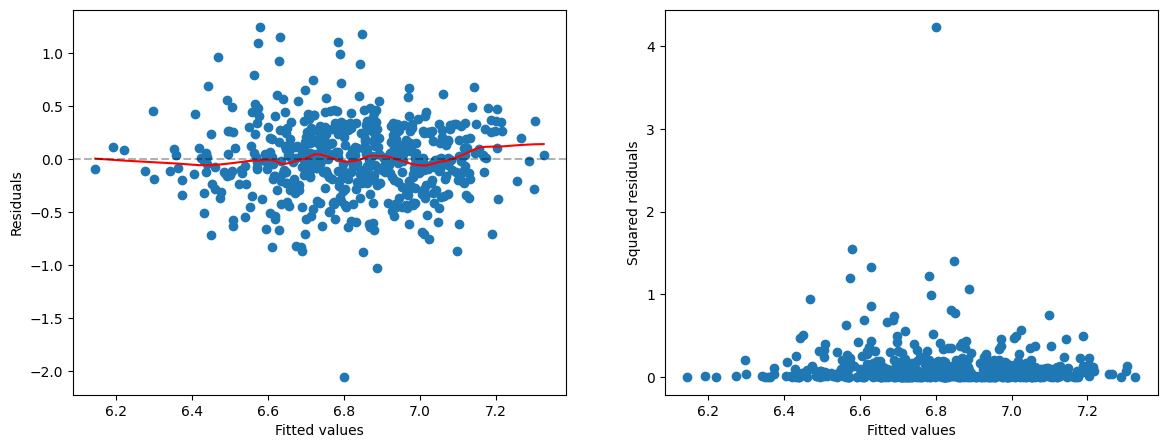

In [497]:
fig = plt.figure(figsize=(14,5))
ax1=fig.add_subplot(1,2,1)
ax2=fig.add_subplot(1,2,2)
ax1.scatter(model7.fittedvalues,model7.resid)
z1=lowess(model7.resid,model7.fittedvalues,frac=1./5)
ax1.plot(z1[:,0],z1[:,1],'red')
ax1.set_xlabel('Fitted values')
ax1.set_ylabel('Residuals')
ax1.axhline(color='Black',alpha=0.3,linestyle='--')
resid72=model7.resid**2
ax2.scatter(model7.fittedvalues,resid72)
ax2.set_xlabel('Fitted values')
ax2.set_ylabel('Squared residuals')
plt.show()

### LSA assumptions

**LSA 1**: The LOWESS smoothed plot of residuals against fitted values appears mostly flat, with only minor deviations at the extremes. This suggests that the relationship between the predictors and $lwage$ is approximately linear, satisfying the linearity assumption.

**LSA 2**: Residuals are generally centered around zero without systematic patterns, indicating that the expected value of the error term given the predictors is close to zero. This supports the assumption that $E(\epsilon|X) = 0$

**LSA 3**: The data is cross-sectional and lacks clustering or time structure, so this assumption is reasonably satisfied.

**LSA 4**: Visual inspection of residual shows some outliers but no severe skewness or heavy tails. Predictors such as $IQ$ and $KWW$ are bounded and roughly symmetric. Thus, this assumption is likely to hold.

**LSA 5**: VIF values are not excessively high, so multicollinearity does not pose a major concern.

**LSA 6**: The spread of residuals and squared residuals remains relatively consistent across the range of fitted values. There is no clear pattern of increasing or decreasing variance, suggesting that the constant variance assumption holds.



### Errors

In [498]:
y_test = test['lwage']
y_pred7 = model7.predict(test)

results_df7 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred7})
eval_model7 = sm.OLS(results_df7['Actual'], sm.add_constant(results_df7['Predicted'])).fit()
rmfse7 = np.sqrt(np.mean((y_test - y_pred7) ** 2))
mafe7 = np.mean(np.abs(y_test - y_pred7))
print(rmfse7)
print(mafe7)

0.34948432697512993
0.2660374469864727


### Evaluation of fit

In [499]:
print(eval_model7.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.356
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     67.49
Date:                Sat, 31 May 2025   Prob (F-statistic):           2.57e-13
Time:                        11:44:54   Log-Likelihood:                -43.089
No. Observations:                 124   AIC:                             90.18
Df Residuals:                     122   BIC:                             95.82
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.4151      1.119     -2.158      0.0

### Scatter plot: actual vs predicted

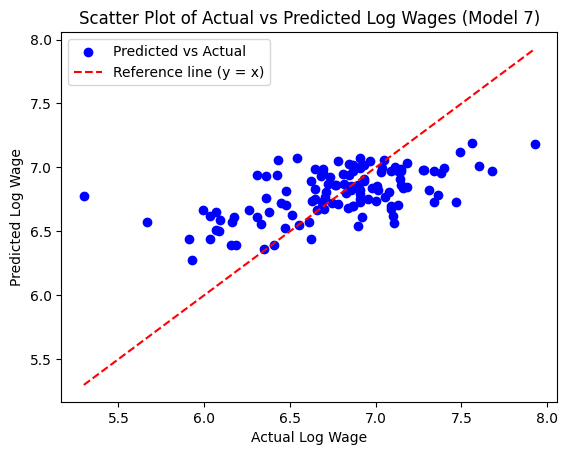

In [500]:
y_pred7 = model7.predict(test)

# Create DataFrame with actual and predicted values
results_df7 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred7})

# Create scatter plot
plt.scatter(results_df7['Actual'], results_df7['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df7['Actual'].min(), results_df7['Predicted'].min())
max_val = max(results_df7['Actual'].max(), results_df7['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 7)')
plt.legend()

# Show plot
plt.show()

## **Other best models for predicting**

### **Model 4**

In [501]:
model4 = 'lwage ~ educ + exper + IQ + meduc + urban + married + log_tenure + educ_exper'
model4 = smf.ols(formula=model4, data=train_drop).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.253
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     22.10
Date:                Sat, 31 May 2025   Prob (F-statistic):           4.38e-29
Time:                        11:44:54   Log-Likelihood:                -201.94
No. Observations:                 531   AIC:                             421.9
Df Residuals:                     522   BIC:                             460.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.6857      0.317     17.914      0.0

#### Error terms

In [502]:
y_test = test['lwage']
y_pred4 = model4.predict(test)

results_df4 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred4})
eval_model4 = sm.OLS(results_df4['Actual'], sm.add_constant(results_df4['Predicted'])).fit()
rmfse4 = np.sqrt(np.mean((y_test - y_pred4) ** 2))
mafe4 = np.mean(np.abs(y_test - y_pred4))
print(rmfse4)
print(mafe4)

0.3573888364749632
0.27207651660196575


#### Evaluation of fit

In [503]:
print(eval_model4.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.320
Model:                            OLS   Adj. R-squared:                  0.315
Method:                 Least Squares   F-statistic:                     57.46
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.48e-12
Time:                        11:44:54   Log-Likelihood:                -46.462
No. Observations:                 124   AIC:                             96.92
Df Residuals:                     122   BIC:                             102.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1962      1.184     -1.854      0.0

#### Scatter plot: actual vs predicted

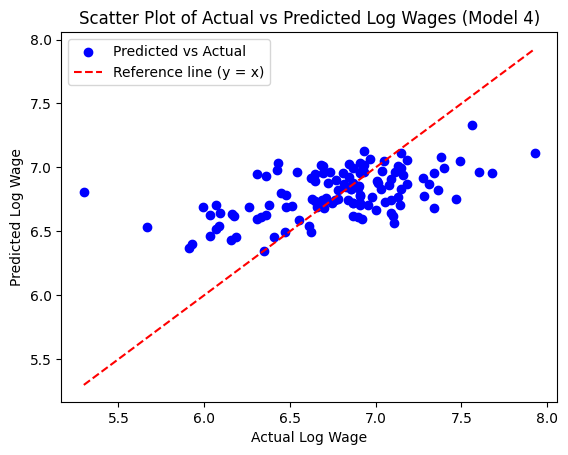

In [504]:
y_pred4 = model4.predict(test)

# Create DataFrame with actual and predicted values
results_df4 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred4})

# Create scatter plot
plt.scatter(results_df4['Actual'], results_df4['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df4['Actual'].min(), results_df4['Predicted'].min())
max_val = max(results_df4['Actual'].max(), results_df4['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 4)')
plt.legend()

# Show plot
plt.show()

### **Model 10**

In [505]:
model10 = 'lwage ~ educ + exper + IQ + meduc + urban + married + age + log_tenure + log_hours + age_educ'
model10 = smf.ols(formula=model10, data=train_drop).fit()
print(model10.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     18.35
Date:                Sat, 31 May 2025   Prob (F-statistic):           7.07e-29
Time:                        11:44:54   Log-Likelihood:                -199.14
No. Observations:                 531   AIC:                             420.3
Df Residuals:                     520   BIC:                             467.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6949      1.191      6.460      0.0

#### Errors

In [506]:
test['hourssqrt'] = np.sqrt(test['hours'])
y_test = test['lwage']
test['spline_educ_15'] = np.maximum(0, test['educ'] - 15)
test['spline_age_35'] = np.maximum(0, test['age'] - 35)
y_pred10 = model10.predict(test)

results_df10 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred10})
eval_model10 = sm.OLS(results_df10['Actual'], sm.add_constant(results_df10['Predicted'])).fit()
rmfse10 = np.sqrt(np.mean((y_test - y_pred10) ** 2))
mafe10 = np.mean(np.abs(y_test - y_pred10))
print(rmfse10)
print(mafe10)

0.3426570009794508
0.2629941584303184


#### Evaluation of fit

In [507]:
print(eval_model10.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     79.65
Date:                Sat, 31 May 2025   Prob (F-statistic):           5.52e-15
Time:                        11:44:54   Log-Likelihood:                -39.235
No. Observations:                 124   AIC:                             82.47
Df Residuals:                     122   BIC:                             88.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0439      1.101     -2.765      0.0

#### Scatter plot: actual vs predicted

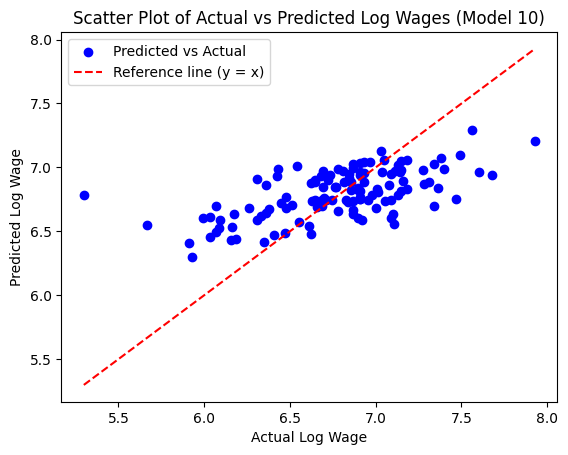

In [508]:
y_pred10 = model10.predict(test)

# Create DataFrame with actual and predicted values
results_df10 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred10})

# Create scatter plot
plt.scatter(results_df10['Actual'], results_df10['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df10['Actual'].min(), results_df10['Predicted'].min())
max_val = max(results_df10['Actual'].max(), results_df10['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 10)')
plt.legend()

# Show plot
plt.show()

### **Model 13**

In [509]:
model13 = 'lwage ~ educ + exper + meduc + IQ + urban + married + log_tenure  + south'
model13 = smf.ols(formula=model13, data=train_drop).fit()
print(model13.summary())

                            OLS Regression Results                            
Dep. Variable:                  lwage   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     21.68
Date:                Sat, 31 May 2025   Prob (F-statistic):           1.47e-28
Time:                        11:44:54   Log-Likelihood:                -203.22
No. Observations:                 531   AIC:                             424.4
Df Residuals:                     522   BIC:                             462.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0851      0.159     31.984      0.0

#### Errors

In [510]:
y_pred13 = model13.predict(test)

results_df13 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred13})
eval_model13 = sm.OLS(results_df13['Actual'], sm.add_constant(results_df13['Predicted'])).fit()
rmfse13 = np.sqrt(np.mean((y_test - y_pred13) ** 2))
mafe13 = np.mean(np.abs(y_test - y_pred13))
print(rmfse13)
print(mafe13)

0.350045322041723
0.27060054743849954


#### Evaluation of fit

In [511]:
print(eval_model13.summary())

                            OLS Regression Results                            
Dep. Variable:                 Actual   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.348
Method:                 Least Squares   F-statistic:                     66.62
Date:                Sat, 31 May 2025   Prob (F-statistic):           3.43e-13
Time:                        11:44:54   Log-Likelihood:                -43.377
No. Observations:                 124   AIC:                             90.75
Df Residuals:                     122   BIC:                             96.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2792      1.110     -2.053      0.0

#### Scatter plot: actual vs predicted

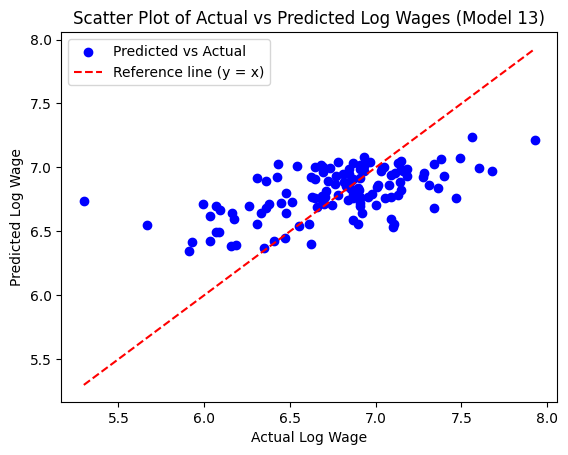

In [512]:
# Create DataFrame with actual and predicted values
results_df13 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred13})

# Create scatter plot
plt.scatter(results_df13['Actual'], results_df13['Predicted'], color='blue', label='Predicted vs Actual')

# Add reference line y = x
min_val = min(results_df13['Actual'].min(), results_df13['Predicted'].min())
max_val = max(results_df13['Actual'].max(), results_df13['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Reference line (y = x)')

# Add labels and title
plt.xlabel('Actual Log Wage')
plt.ylabel('Predicted Log Wage')
plt.title('Scatter Plot of Actual vs Predicted Log Wages (Model 13)')
plt.legend()

# Show plot
plt.show()

## **Summary table: best models (4, 7, 10, 13)**

In [513]:
# Define the data
fourmodels = {
    'Model': [4, 7, 10, 13],
    'RMSFE': [rmfse4, rmfse7, rmfse10, rmfse13],
    'MAFE': [mafe4, mafe7, mafe10, mafe13],
    'R²_adj': [eval_model4.rsquared_adj, eval_model7.rsquared_adj, eval_model10.rsquared_adj, eval_model13.rsquared_adj],
    'p': [model4.df_model, model7.df_model, model10.df_model, model13.df_model]
}

# Create the DataFrame
df_four = pd.DataFrame(fourmodels)

# Display the DataFrame
print(df_four)

   Model     RMSFE      MAFE    R²_adj     p
0      4  0.357389  0.272077  0.314608   8.0
1      7  0.349484  0.266037  0.350901   9.0
2     10  0.342657  0.262994  0.390024  10.0
3     13  0.350045  0.270601  0.347880   8.0
